# HR-ETE-GNN — Preliminary Results

### A full end-to-end run of the thesis experiment, deliberately scaled down so it finishes in minutes

---

**What this notebook is.** Every stage of the final experiment, in order, start to finish: data → Hurst regimes → Rényi ER-TE graph estimation → matched-density graphs → multi-seed GNN training → forecasts → the four RQ1 hypothesis tests → the two RQ2 hypothesis tests → the reporting template. Nothing is skipped, stubbed, or filled in with invented numbers. Every table below is computed from real data by the same code the final run will use.

**What this notebook is not.** It is not the result. Five knobs — sample length, α grid, surrogate count, training seeds, training epochs — are turned down far enough that the whole experiment finishes in minutes rather than days. That buys speed at the direct cost of *statistical power* and *estimator precision*. The **shape** of every table below is final. The **numbers** in them are not, and no claim in the thesis may cite them.

**Why produce it at all.** Three reasons, and they are also the reasons to read it:

1. **It proves the pipeline runs end to end.** Every alignment assertion, every look-ahead guard, every FDR correction executes on real data and passes. Whatever the final numbers turn out to be, they will not be held up by a broken pipeline discovered late.
2. **It fixes the reporting format before the results exist.** Each hypothesis below produces exactly the table that will appear in the results chapter, with the same columns in the same order. Freezing the format *before* seeing real results is the cheapest available defence against the charge of test-shopping.
3. **It surfaces the binding constraints while they can still be fixed.** Two are already quantified below — a crisis-day shortage that makes H1b unrunnable at this sample length (§3), and a permutation-*p* floor that caps how many edges H2a can ever detect (§4). Both are scope artefacts, both have known fixes, and both are far cheaper to find now than in the week before the defence.

---

### How to read the tables

Every results table in this notebook carries one of three banners:

| Banner | Meaning |
|---|---|
| 🟩 **NUMBERS FINAL** | Scope reduction does not affect this. Descriptive statistics, sample calendars, alignment checks. Quote freely. |
| 🟨 **NUMBERS PROVISIONAL** | The full run produces this same table more precisely. The sign and rough magnitude may survive; the *p*-values will move. Do not quote. |
| 🟥 **NUMBERS NOT INTERPRETABLE** | The test is structurally underpowered at preliminary scope. A null here is evidence of nothing, and the direction should not be read either. |

---

## §0 — The scope contract

This is the most important cell in the notebook. It states exactly which knobs were turned down, by how much, and — the part that matters — **what each reduction costs**.

The distinction to hold onto: the reductions fall into two classes.

- **Precision reductions** (surrogates, seeds, epochs, bootstrap draws) make each estimate noisier without changing what is being estimated. Turning them back up sharpens the same picture.
- **Sample reductions** (start date, α grid) change *which* data and *which* models are in the experiment. These do not merely blur the picture, they change it — a shorter sample contains fewer crisis days, and crisis days are the entire subject of H1b.

Only the first class can be reasoned through by extrapolation. The second class is the reason the preliminary numbers are not previews of the final ones.

In [1]:
import sys, os, time, warnings
from pathlib import Path

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
# The ER-TE estimator, the model and the training protocol are NOT re-implemented
# here.  They are imported from the same module the full thesis run uses, so the
# preliminary and the final numbers come out of identical code and only the
# configuration below differs.  A third private copy of the estimator is exactly
# how two notebooks start quietly disagreeing with each other.
sys.path.insert(0, str(ROOT / ".build"))

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from scipy import stats as sps

import core as hr                       # ER-TE, splits, model, multi-seed training
from thesis_stats import (
    qlike, mse, mae, newey_west_lrv,
    diebold_mariano, giacomini_white,
    benjamini_hochberg, model_confidence_set,
    har_rv_forecast, random_walk_forecast,
    min_detectable_effect, stationary_bootstrap_indices,
)

OUT = ROOT / "preliminary_results"; OUT.mkdir(exist_ok=True)
CACHE = OUT / "prices_cache.csv"
T_START = time.time()
def stamp(msg): print(f"[{time.time()-T_START:6.1f}s] {msg}", flush=True)

pd.set_option("display.precision", 4); pd.set_option("display.width", 150)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": .25, "grid.linewidth": .6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 11, "figure.facecolor": "white",
    "axes.labelsize": 9.5, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5, "legend.frameon": False, "font.size": 9.5,
})
INK, ACCENT, CALM, WARN, GREY = "#1a1a2e", "#e94560", "#16a085", "#f39c12", "#9AA0A6"

print("environment ready | numpy", np.__version__, "| torch", torch.__version__)

environment ready | numpy 2.5.2 | torch 2.14.0+cpu


In [2]:
# ===========================================================================
#  PRE-REGISTRATION  --  identical to the full run, frozen before any result is
#  inspected.  Scope reduction NEVER touches this block.  If a preliminary result
#  were allowed to change the primary metric or the direction of the alternative,
#  the whole exercise would be test-shopping with extra steps.
# ===========================================================================
PRIMARY_METRIC      = "QLIKE"                        # Patton (2011) proxy-robust
PRIMARY_TEST        = "Giacomini-White (2006), HAC"
PRIMARY_ALTERNATIVE = "greater"                      # one-sided: Renyi beats Shannon
PRIMARY_LEVEL       = 0.05
PRIMARY_ALPHA_ARM   = 0.5                            # the ONE pre-specified alpha for H1a
SECONDARY_FDR_Q     = 0.10                           # BH across the 10 ETFs / 90 pairs
MCS_CONFIDENCE      = 0.90
MIN_MEANINGFUL_GAIN = 0.05                           # 5% QLIKE reduction = smallest claim worth making

TICKERS = ["EWA","EWC","EWG","EWJ","EWT","EWU","EWW","EWY","EWZ","EZA"]
COUNTRY = dict(zip(TICKERS, ["Australia","Canada","Germany","Japan","Taiwan",
                             "UK","Mexico","South Korea","Brazil","South Africa"]))
REGIME_PROXY = "URTH"
LOOKBACK = RV_WINDOW = 20
TRAIN_FRAC, VAL_FRAC = 0.60, 0.20
KNN_K     = 4
MATCHED_K = 20          # edges per matched-density graph

# ===========================================================================
#  THE SCOPE SWITCH.  Set MODE = "thesis" and this same notebook becomes the
#  full run.  Nothing else in the notebook changes.
# ===========================================================================
MODE = "preliminary"

SCOPE = {
    "preliminary": dict(start="2018-01-01", end="2024-05-29",
                        alpha_grid=[0.5, 1.0, 1.5],
                        m_surrogates=100, seeds=3, epochs=200, patience=40,
                        lr=1e-2, mcs_B=400, boot_B=400),
    "thesis":      dict(start="2003-02-07", end="2024-05-29",
                        alpha_grid=[0.3, 0.5, 0.7, 0.9, 1.0, 1.1, 1.5],
                        m_surrogates=1000, seeds=20, epochs=3000, patience=150,
                        lr=1e-2, mcs_B=2000, boot_B=2000),
}
CFG  = SCOPE[MODE]; FULL = SCOPE["thesis"]
START, END   = CFG["start"], CFG["end"]
ALPHA_GRID   = CFG["alpha_grid"]
M_SURROGATES = CFG["m_surrogates"]
SEEDS        = list(range(CFG["seeds"]))
EPOCHS, PATIENCE, LR = CFG["epochs"], CFG["patience"], CFG["lr"]
MCS_B, BOOT_B = CFG["mcs_B"], CFG["boot_B"]

torch.set_num_threads(4)   # measured optimum on a 12-core box; the network is tiny

contract = pd.DataFrame([
    ("Sample start", START, FULL["start"], "SAMPLE",
     "Fewer crisis days in the test block. Directly caps H1b -- see §3."),
    ("alpha grid", str(ALPHA_GRID), str(FULL["alpha_grid"]), "SAMPLE",
     "Fewer models in the MCS; a coarser read on how the effect varies with alpha."),
    ("Surrogates per pair", M_SURROGATES, FULL["m_surrogates"], "PRECISION",
     f"Permutation p cannot fall below 1/(m+1) = {1/(M_SURROGATES+1):.4f}. Caps H2a -- see §4."),
    ("Training seeds per arm", len(SEEDS), FULL["seeds"], "PRECISION",
     "Noisier seed-ensemble forecast; wider across-seed spread."),
    ("Training epochs", EPOCHS, FULL["epochs"], "PRECISION",
     "Arms compared before convergence -- all arms alike, but not by equal amounts."),
    ("Early-stopping patience", PATIENCE, FULL["patience"], "PRECISION",
     "Truncates slow learners more than fast ones (the known LSTM/GNN asymmetry)."),
    ("MCS bootstrap draws", MCS_B, FULL["mcs_B"], "PRECISION",
     f"MCS p-values granular to ~1/B = {1/MCS_B:.4f}."),
], columns=["Knob", f"This run ({MODE})", "Thesis run", "Class",
            "What the reduction costs"])

print(f"MODE = {MODE.upper()}\n")
print(f"Pre-registered primary : {PRIMARY_METRIC} / {PRIMARY_TEST},"
      f" one-sided '{PRIMARY_ALTERNATIVE}' at {PRIMARY_LEVEL}")
print(f"Pre-registered H1a arm : alpha = {PRIMARY_ALPHA_ARM}"
      f"  (fixed in advance, NOT chosen as the best performer)\n")
display(contract.style.hide(axis="index"))

MODE = PRELIMINARY

Pre-registered primary : QLIKE / Giacomini-White (2006), HAC, one-sided 'greater' at 0.05
Pre-registered H1a arm : alpha = 0.5  (fixed in advance, NOT chosen as the best performer)



Knob,This run (preliminary),Thesis run,Class,What the reduction costs
Sample start,2018-01-01,2003-02-07,SAMPLE,Fewer crisis days in the test block. Directly caps H1b -- see §3.
alpha grid,"[0.5, 1.0, 1.5]","[0.3, 0.5, 0.7, 0.9, 1.0, 1.1, 1.5]",SAMPLE,Fewer models in the MCS; a coarser read on how the effect varies with alpha.
Surrogates per pair,100,1000,PRECISION,Permutation p cannot fall below 1/(m+1) = 0.0099. Caps H2a -- see §4.
Training seeds per arm,3,20,PRECISION,Noisier seed-ensemble forecast; wider across-seed spread.
Training epochs,200,3000,PRECISION,"Arms compared before convergence -- all arms alike, but not by equal amounts."
Early-stopping patience,40,150,PRECISION,Truncates slow learners more than fast ones (the known LSTM/GNN asymmetry).
MCS bootstrap draws,400,2000,PRECISION,MCS p-values granular to ~1/B = 0.0025.


---

## §1 — Data

🟩 **NUMBERS FINAL** for the window actually loaded. The descriptive statistics below are not affected by any of the precision knobs; they change only if the sample window changes.

Ten single-country iShares MSCI ETFs (Table 4 of Lee & Cho, 2025), plus `URTH` as the Hurst regime proxy. Realized volatility is the 20-day rolling root-mean-square of percentage log-returns — the same target the baseline replication uses, so the two experiments forecast literally the same series.

The download is cached to `preliminary_results/prices_cache.csv` on the first run, so re-running the notebook costs nothing and — more importantly — every re-run sees byte-identical data. Delete the cache to refresh.

In [3]:
if CACHE.exists():
    raw = pd.read_csv(CACHE, index_col=0, parse_dates=True)
    src = f"cache ({CACHE.name})"
else:
    import yfinance as yf
    raw = yf.download(TICKERS + [REGIME_PROXY], start=START, end=END,
                      auto_adjust=True, progress=False)["Close"].dropna()
    raw.to_csv(CACHE); src = "yfinance (now cached)"

raw = raw.loc[START:END]
log_ret = np.log(raw / raw.shift(1)).dropna()
rv = (100 * log_ret).pow(2).rolling(RV_WINDOW).mean().pow(0.5).dropna()

stamp(f"data from {src}")
print(f"  prices      : {raw.shape[0]:,} days x {raw.shape[1]} series "
      f"({raw.index.min().date()} -> {raw.index.max().date()})")
print(f"  log-returns : {log_ret.shape}")
print(f"  realized vol: {rv.shape}   (target = {RV_WINDOW}-day rolling RMS of 100*log-returns)")

desc = rv[TICKERS].describe().T[["mean", "std", "min", "max"]]
desc.insert(0, "country", [COUNTRY[t] for t in desc.index])
desc["skew"] = rv[TICKERS].skew(); desc["kurtosis"] = rv[TICKERS].kurtosis()
print("\n[T1] REALIZED VOLATILITY, DESCRIPTIVE STATISTICS   (daily %, "
      f"{rv.index.min().date()} to {rv.index.max().date()})")
display(desc.round(3))
desc.round(4).to_csv(OUT / "T1_descriptives.csv")

[   0.3s] data from cache (prices_cache.csv)
  prices      : 1,611 days x 11 series (2018-01-02 -> 2024-05-28)
  log-returns : (1610, 11)
  realized vol: (1591, 11)   (target = 20-day rolling RMS of 100*log-returns)

[T1] REALIZED VOLATILITY, DESCRIPTIVE STATISTICS   (daily %, 2018-01-31 to 2024-05-28)


,country,mean,std,min,max,skew,kurtosis
EWA,Australia,1.275,0.960,0.466,8.879,5.491,35.506
EWC,Canada,1.088,0.767,0.320,7.053,4.928,30.908
EWG,Germany,1.254,0.741,0.402,6.101,3.369,15.984
EWJ,Japan,1.008,0.458,0.368,4.161,3.492,18.712
EWT,Taiwan,1.223,0.546,0.508,5.001,3.702,20.479
EWU,UK,1.093,0.709,0.371,6.228,4.249,23.929
EWW,Mexico,1.478,0.774,0.681,7.119,4.248,23.315
EWY,South Korea,1.510,0.731,0.697,7.177,4.837,30.709
EWZ,Brazil,2.059,1.185,0.978,11.417,5.383,36.147
EZA,South Africa,1.913,0.839,0.745,8.110,4.329,25.724


---

## §2 — Chronological splits, and the two look-ahead guards

🟩 **NUMBERS FINAL** — this is a calendar, not an estimate.

Three-way chronological split: 60% train / 20% validation / 20% test. Three-way rather than two-way because **α, the learning rate and the stopping epoch all have to be chosen somewhere**, and if any of them is chosen on the test block then every *p*-value computed on the test block is void. The validation block exists precisely so that choice has somewhere legitimate to happen.

Two guards run below and both are hard assertions, not comments:

1. **The graph never sees the test block.** The ER-TE adjacency in §4 is estimated on returns up to the last *training* date only. (The pilot built it from `log_ret.iloc[-600:]`, which overlapped the test set — the first thing a quantitative panellist checks, and on its own fatal to any significance claim.)
2. **The non-neural baselines are aligned to the same targets.** `har_rv_forecast` indexes from `max(lags)`, not from `LOOKBACK`; an off-by-one there silently pairs each forecast with the wrong day and quietly flatters or damns every model at once. The assertion in §7 pins the random-walk forecast to the previous day's RV exactly.

In [4]:
sp = hr.make_splits(rv[TICKERS].values, lookback=LOOKBACK,
                    train_frac=TRAIN_FRAC, val_frac=VAL_FRAC)

dates = rv.index
cal = pd.DataFrame([
    ("train", len(sp["X_train"]), dates[sp["t_train"][0]].date(), dates[sp["t_train"][-1]].date()),
    ("validation", len(sp["X_val"]), dates[sp["t_val"][0]].date(), dates[sp["t_val"][-1]].date()),
    ("test", len(sp["X_test"]), dates[sp["t_test"][0]].date(), dates[sp["t_test"][-1]].date()),
], columns=["block", "supervised samples", "first target", "last target"])

print("[T2] SPLIT CALENDAR   (one supervised sample = 20 days of RV -> next day's RV, "
      "for all 10 ETFs jointly)")
display(cal.style.hide(axis="index"))

last_train_date = dates[sp["t_train"][-1]]
first_test_date = dates[sp["t_test"][0]]
train_ret = log_ret.loc[:last_train_date, TICKERS]

assert last_train_date < first_test_date, "training window overlaps the test window"
print(f"\nGraph estimation window : {train_ret.index.min().date()} -> "
      f"{train_ret.index.max().date()}  ({len(train_ret):,} return days)")
print(f"Test window opens       : {first_test_date.date()}")
print(f"Gap                     : {(first_test_date - last_train_date).days} calendar days"
      "  -- the graph cannot have seen the test block.")

T_TEST = len(sp["y_test"])
cal.to_csv(OUT / "T2_split_calendar.csv", index=False)

[T2] SPLIT CALENDAR   (one supervised sample = 20 days of RV -> next day's RV, for all 10 ETFs jointly)


block,supervised samples,first target,last target
train,942,2018-03-02,2021-11-24
validation,314,2021-11-26,2023-02-27
test,314,2023-02-28,2024-05-28



Graph estimation window : 2018-01-03 -> 2021-11-24  (982 return days)
Test window opens       : 2023-02-28
Gap                     : 461 calendar days  -- the graph cannot have seen the test block.


---

## §3 — Power audit, run *before* any result is looked at

🟥 **This section decides whether §9 (H1b) is readable at all.** It is placed here, ahead of every result, deliberately: the crisis-day count and the minimum detectable effect are properties of the *design*, not of the outcome, so they can be computed and committed to before the outcome exists. Reading them afterwards invites the temptation to treat a shortage of power as an inconvenient detail rather than a disqualifying one.

The regime indicator is the same one the thesis title claims: a 250-day rolling R/S Hurst exponent on the World-ETF proxy, thresholded at *H* < 0.5 (anti-persistent ⇒ "turbulent"), then **lagged one day** so it is genuinely known at the moment the forecast is made.

Two numbers matter:

- **Turbulent days inside the test block.** H1b's entire content is the difference between turbulent and calm days. If the test block contains a handful of turbulent days, the regime coefficient is estimated off a handful of observations and the test cannot reject anything, whatever the truth is.
- **Minimum detectable effect.** The smallest standardised loss differential a DM/GW test can detect at 5% with 80% power, given this many test days. If the effect the model actually produces is smaller than this, a null result says only that the test set is short.

*On the mapping itself:* "H < 0.5 = turbulent" is an assumption, not a definition — anti-persistence means mean-reversion, which correlates with crises without being the same thing. §9 therefore runs H1b a second time against an explicit high-volatility crisis dummy, and agreement between the two is itself a result.

In [5]:
def hurst_rs(series):
    """Rescaled-range Hurst estimator (literal, uncorrected -- the variant that
    reproduces the paper's regime count in the baseline replication)."""
    s = np.asarray(series, float); N = len(s)
    if N < 20: return np.nan
    out = []
    for lag in np.unique(np.logspace(1, np.log10(N // 2), 10).astype(int)):
        vals = []
        for j in range(N // lag):
            seg = s[j*lag:(j+1)*lag]; sd = seg.std(ddof=1)
            if sd > 0:
                dev = np.cumsum(seg - seg.mean()); vals.append((dev.max() - dev.min()) / sd)
        if vals: out.append((lag, np.mean(vals)))
    if len(out) < 2: return np.nan
    L, R = zip(*out); return np.polyfit(np.log(L), np.log(R), 1)[0]

hurst = log_ret[REGIME_PROXY].rolling(250).apply(hurst_rs, raw=True).dropna()
regime_full = (hurst < 0.5).astype(float).shift(1).dropna()      # lag by one day
test_dates  = dates[sp["t_test"]]
regime_test = regime_full.reindex(test_dates).fillna(0.0).values
n_crisis    = int(regime_test.sum())

# --- a second, independent crisis definition (hypotheses doc, issue #5) -----
# Cross-sectional realized volatility above its OWN trailing 250-day 80th
# percentile, then lagged one day.  Two properties matter:
#   * no look-ahead -- the quantile at date t uses only dates <= t;
#   * it is RELATIVE, not absolute -- "turbulent compared with the past year".
# A fixed threshold set on the training block would be the more natural crisis
# definition, but this sample's training block contains COVID, so that threshold
# lands above everything in the calm 2023-24 test block and flags zero days. Both
# quantities are computed below so the difference is visible rather than hidden.
xs_rv = rv[TICKERS].mean(axis=1)
thr_fixed = xs_rv.iloc[:sp["t_train"][-1]].quantile(0.80)
fixed_test = (xs_rv > thr_fixed).astype(float).shift(1).reindex(test_dates).fillna(0.0).values
n_fixed = int(fixed_test.sum())

thr_roll   = xs_rv.rolling(250, min_periods=120).quantile(0.80)
hivol_full = (xs_rv > thr_roll).astype(float).shift(1).dropna()
hivol_test = hivol_full.reindex(test_dates).fillna(0.0).values
n_hivol    = int(hivol_test.sum())

mde = min_detectable_effect(T_TEST, alpha=PRIMARY_LEVEL, power=0.80, one_sided=True)

print("[T3] POWER AUDIT\n")
power = pd.DataFrame([
    ("Test days (T)", T_TEST, "sample size for every RQ1 test"),
    ("Turbulent days, whole sample", f"{int((hurst < 0.5).sum()):,} / {len(hurst):,} "
     f"({100*(hurst < 0.5).mean():.1f}%)", "Hurst H < 0.5 on the World proxy"),
    ("Turbulent days IN TEST BLOCK", f"{n_crisis} / {T_TEST} ({100*regime_test.mean():.1f}%)",
     "<<< this is what H1b is estimated from"),
    ("High-vol days IN TEST BLOCK (relative)",
     f"{n_hivol} / {T_TEST} ({100*hivol_test.mean():.1f}%)",
     "above trailing 250-day 80th pct -- adaptive, stays populated"),
    ("High-vol days IN TEST BLOCK (absolute)",
     f"{n_fixed} / {T_TEST} ({100*fixed_test.mean():.1f}%)",
     "above a threshold fixed on the training block (which contains COVID)"),
    ("Min detectable mean(d)/sd(d) at 5%", f"{mde['mde_ratio_at_significance']:.4f}",
     "below this, nothing is significant however true"),
    ("Min detectable mean(d)/sd(d) at 80% power", f"{mde['mde_ratio_at_power']:.4f}",
     "below this, a null result is uninformative"),
], columns=["Quantity", "Value", "How to read it"])
display(power.style.hide(axis="index"))

H1B_READABLE = n_crisis >= 150
if not H1B_READABLE:
    print(f"\n{'='*78}")
    print("  *** H1b IS NOT EVALUABLE AT PRELIMINARY SCOPE ***")
    print(f"  The test block contains {n_crisis} turbulent day(s). The regime coefficient")
    print("  in §9 will be estimated from those days alone. Its point estimate, its")
    print("  standard error and its p-value are all reported below FOR FORMAT ONLY.")
    print("  A null there is evidence of nothing, and the sign should not be read.")
    print("")
    print(f"  Cause: the sample starts {START}, so the test block lands in a calm")
    print(f"  stretch. The thesis run starts {FULL['start']}, spanning 2008 and 2020,")
    print("  and its test block is the one this hypothesis needs.")
    print(f"{'='*78}")
if n_fixed == 0:
    print(f"\n  Note: the ABSOLUTE high-volatility dummy flags 0 of {T_TEST} test days.")
    print("  The two crisis definitions agree with each other: by 2023-24 standards")
    print(f"  nothing in this test block is a crisis. That is a property of the "
          f"{START[:4]}-start\n  window, not of the model, and it is the finding this "
          "section exists to surface.")
else:
    print(f"\n  {n_crisis} turbulent days in the test block -- H1b is estimable.")

power.to_csv(OUT / "T3_power_audit.csv", index=False)

[T3] POWER AUDIT



Quantity,Value,How to read it
Test days (T),314,sample size for every RQ1 test
"Turbulent days, whole sample","130 / 1,361 (9.6%)",Hurst H < 0.5 on the World proxy
Turbulent days IN TEST BLOCK,4 / 314 (1.3%),<<< this is what H1b is estimated from
High-vol days IN TEST BLOCK (relative),11 / 314 (3.5%),"above trailing 250-day 80th pct -- adaptive, stays populated"
High-vol days IN TEST BLOCK (absolute),0 / 314 (0.0%),above a threshold fixed on the training block (which contains COVID)
Min detectable mean(d)/sd(d) at 5%,0.0928,"below this, nothing is significant however true"
Min detectable mean(d)/sd(d) at 80% power,0.1403,"below this, a null result is uninformative"



  *** H1b IS NOT EVALUABLE AT PRELIMINARY SCOPE ***
  The test block contains 4 turbulent day(s). The regime coefficient
  in §9 will be estimated from those days alone. Its point estimate, its
  standard error and its p-value are all reported below FOR FORMAT ONLY.
  A null there is evidence of nothing, and the sign should not be read.

  Cause: the sample starts 2018-01-01, so the test block lands in a calm
  stretch. The thesis run starts 2003-02-07, spanning 2008 and 2020,
  and its test block is the one this hypothesis needs.

  Note: the ABSOLUTE high-volatility dummy flags 0 of 314 test days.
  The two crisis definitions agree with each other: by 2023-24 standards
  nothing in this test block is a crisis. That is a property of the 2018-start
  window, not of the model, and it is the finding this section exists to surface.


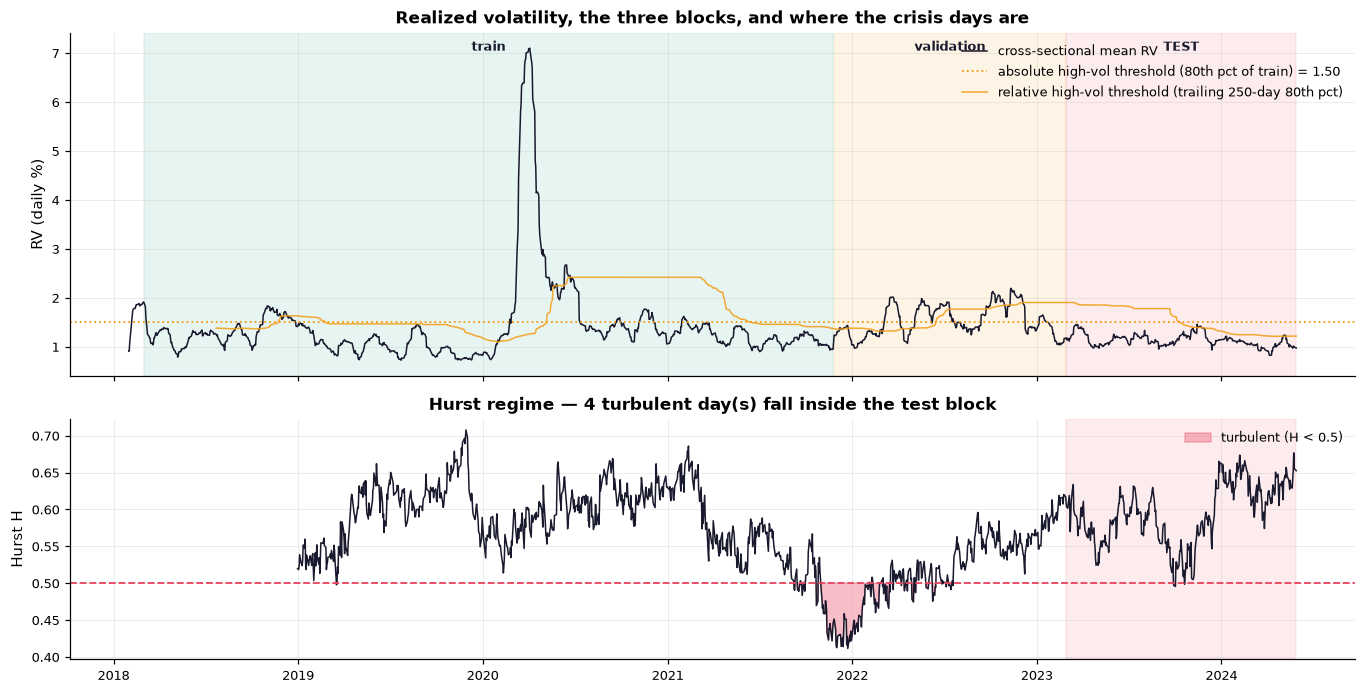

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12.5, 6.4), sharex=True,
                               height_ratios=[2, 1.4])

ax1.plot(rv.index, rv[TICKERS].mean(axis=1), color=INK, lw=1.0,
         label="cross-sectional mean RV")
ax1.axhline(thr_fixed, color=WARN, ls=":", lw=1.2,
            label=f"absolute high-vol threshold (80th pct of train) = {thr_fixed:.2f}")
ax1.plot(thr_roll.index, thr_roll.values, color=WARN, lw=1.0, alpha=.85,
         label="relative high-vol threshold (trailing 250-day 80th pct)")
for a, b, lab in [(dates[sp["t_train"][0]], last_train_date, "train"),
                  (dates[sp["t_val"][0]], dates[sp["t_val"][-1]], "validation"),
                  (first_test_date, test_dates[-1], "TEST")]:
    ax1.axvspan(a, b, color=(CALM if lab == "train" else WARN if lab == "validation" else ACCENT),
                alpha=.10)
    ax1.text(a + (b - a) / 2, ax1.get_ylim()[1] * .95, lab, ha="center",
             fontsize=8.5, color=INK, weight="bold")
ax1.set_ylabel("RV (daily %)"); ax1.legend(loc="upper right")
ax1.set_title("Realized volatility, the three blocks, and where the crisis days are")

ax2.plot(hurst.index, hurst.values, color=INK, lw=1.0)
ax2.axhline(0.5, color=ACCENT, ls="--", lw=1.2)
ax2.fill_between(hurst.index, hurst.values, 0.5, where=(hurst.values < 0.5),
                 color=ACCENT, alpha=.35, label="turbulent (H < 0.5)")
ax2.axvspan(first_test_date, test_dates[-1], color=ACCENT, alpha=.10)
ax2.set_ylabel("Hurst H"); ax2.legend(loc="upper right")
ax2.set_title(f"Hurst regime — {n_crisis} turbulent day(s) fall inside the test block")
plt.tight_layout(); plt.savefig(OUT / "F1_sample_and_regimes.png", dpi=130); plt.show()

---

## §4 — RQ2 / H2a: does an ER-TE edge exist at all?

🟨 **NUMBERS PROVISIONAL**, and the surrogate count is the binding constraint — quantified below before the table is read.

For each of the 90 ordered pairs (*i* → *j*), the effective Rényi transfer entropy is measured against a **circular-shift** surrogate null. Circular shift, not full permutation: rotating *Y* destroys the *Y* → *X* cross-dependence while leaving *Y*'s own autocorrelation intact, so the null being tested is "*Y* carries no information about *X* beyond *X*'s own past" rather than "*Y* is i.i.d. noise". Financial returns are serially dependent, so those two nulls are not interchangeable and the pilot's version tested the wrong one.

Each pair yields an exact permutation *p*-value; all 90 then go through Benjamini–Hochberg at *q* = 0.10.

**The constraint.** With *m* surrogates the smallest achievable permutation *p* is 1/(*m*+1). BH at rank *k* compares the *k*-th smallest *p* against *q·k*/90. So no edge can survive unless at least ⌈90/(q(m+1))⌉ pairs sit at the floor simultaneously. The cell computes that number. It is a property of the design, and at preliminary scope it is large — which means **a low edge count at this scope is a statement about the surrogate budget, not about the market**.

In [7]:
def erte_graph(rdf, alpha, m=None, tag=""):
    """All 90 ordered pairs at one alpha: raw ER-TE, z, exact permutation p,
    and the BH-FDR-masked adjacency.  Estimated on whatever window `rdf` is."""
    m = M_SURROGATES if m is None else m
    n = len(TICKERS)
    E = np.zeros((n, n)); Z = np.zeros((n, n)); P = np.ones((n, n))
    t0 = time.time()
    for i, ti in enumerate(TICKERS):
        for j, tj in enumerate(TICKERS):
            if i == j: continue
            e, z, p = hr.effective_rte(rdf[ti].values, rdf[tj].values, alpha=alpha,
                                       k=KNN_K, m_surrogates=m, seed=1000*i + j,
                                       copula=True, surrogate="circular")
            E[i, j], Z[i, j], P[i, j] = e, z, p
    off = ~np.eye(n, dtype=bool)
    keep = hr.benjamini_hochberg_mask(P[off], q=SECONDARY_FDR_Q)
    A = np.zeros((n, n))
    A[off] = np.where(keep & np.isfinite(E[off]), np.maximum(E[off], 0.0), 0.0)
    stamp(f"  ER-TE {tag}alpha={alpha}: {int((A > 0).sum())}/90 edges survive BH "
          f"({time.time()-t0:.0f}s)")
    return dict(E=E, Z=Z, P=P, A_fdr=A, pvals=P[off])

# --- the floor this scope imposes, computed BEFORE the table is read -------
p_floor  = 1.0 / (M_SURROGATES + 1)
k_needed = int(np.ceil(90 * p_floor / SECONDARY_FDR_Q))
p_floor_full  = 1.0 / (FULL["m_surrogates"] + 1)
k_needed_full = int(np.ceil(90 * p_floor_full / SECONDARY_FDR_Q))
print(f"m = {M_SURROGATES} surrogates  ->  smallest achievable p = {p_floor:.4f}")
print(f"  BH at q={SECONDARY_FDR_Q} across 90 pairs therefore needs at least "
      f"{k_needed} pairs at the floor before ANY edge survives.")
print(f"  Thesis run (m = {FULL['m_surrogates']}): floor {p_floor_full:.4f}, "
      f"only {k_needed_full} pair(s) needed.\n")

GRAPH = {a: erte_graph(train_ret, a) for a in ALPHA_GRID}

m = 100 surrogates  ->  smallest achievable p = 0.0099
  BH at q=0.1 across 90 pairs therefore needs at least 9 pairs at the floor before ANY edge survives.
  Thesis run (m = 1000): floor 0.0010, only 1 pair(s) needed.

[  29.7s]   ER-TE alpha=0.5: 36/90 edges survive BH (24s)
[  53.1s]   ER-TE alpha=1.0: 0/90 edges survive BH (23s)
[  76.9s]   ER-TE alpha=1.5: 10/90 edges survive BH (24s)


In [8]:
lab = lambda a: ("Rényi, tail-emphasising" if a < 1 else
                 "SHANNON — the H-ETE-GNN baseline" if a == 1 else
                 "Rényi, bulk-emphasising")
g_summary = pd.DataFrame([
    {"alpha": a, "regime": lab(a),
     "edges after BH-FDR": int((GRAPH[a]["A_fdr"] > 0).sum()),
     "density %": 100 * (GRAPH[a]["A_fdr"] > 0).sum() / 90,
     "pairs at the p-floor": int((GRAPH[a]["pvals"] <= p_floor + 1e-12).sum()),
     "raw p < 0.05": int((GRAPH[a]["pvals"] < 0.05).sum()),
     "smallest p": GRAPH[a]["pvals"].min(),
     "mean |ER-TE|": np.nanmean(np.abs(GRAPH[a]["E"][~np.eye(10, dtype=bool)]))}
    for a in ALPHA_GRID]).set_index("alpha")

print("[T4] H2a — EDGE EXISTENCE, per alpha, training window only, BH-FDR at "
      f"q = {SECONDARY_FDR_Q}")
display(g_summary.round(4))
g_summary.round(5).to_csv(OUT / "T4_h2a_edge_existence.csv")
print("\nRead 'pairs at the p-floor' against the "
      f"{k_needed} needed above: that column, not the market, is what decides")
print("whether the 'edges after BH-FDR' column can be non-zero at this scope.")

[T4] H2a — EDGE EXISTENCE, per alpha, training window only, BH-FDR at q = 0.1


,regime,edges after BH-FDR,density %,pairs at the p-floor,raw p < 0.05,smallest p,mean |ER-TE|
alpha,,,,,,,
0.5,"Rényi, tail-emphasising",36,40.0000,21,39,0.0099,0.0377
1.0,SHANNON — the H-ETE-GNN baseline,0,0.0000,1,13,0.0099,0.0267
1.5,"Rényi, bulk-emphasising",10,11.1111,10,22,0.0099,0.0481



Read 'pairs at the p-floor' against the 9 needed above: that column, not the market, is what decides
whether the 'edges after BH-FDR' column can be non-zero at this scope.


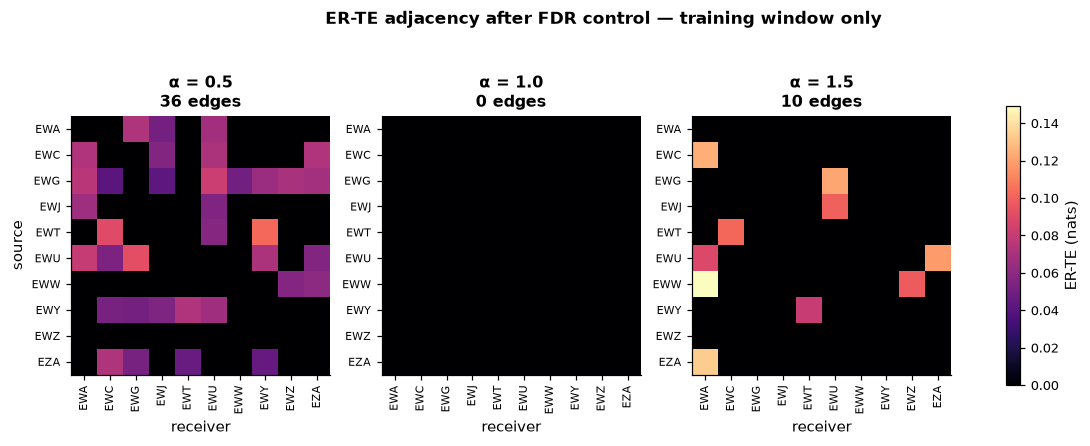

In [9]:
fig, axes = plt.subplots(1, len(ALPHA_GRID), figsize=(4.3 * len(ALPHA_GRID), 4.4))
axes = np.atleast_1d(axes)
vmax = max(GRAPH[a]["A_fdr"].max() for a in ALPHA_GRID) or 1.0
for ax, a in zip(axes, ALPHA_GRID):
    im = ax.imshow(GRAPH[a]["A_fdr"], cmap="magma", vmin=0, vmax=vmax)
    ax.set_xticks(range(10)); ax.set_xticklabels(TICKERS, rotation=90, fontsize=7)
    ax.set_yticks(range(10)); ax.set_yticklabels(TICKERS, fontsize=7)
    ax.set_title(f"α = {a}\n{int((GRAPH[a]['A_fdr'] > 0).sum())} edges", fontsize=10.5)
    ax.set_xlabel("receiver"); ax.grid(False)
axes[0].set_ylabel("source")
fig.colorbar(im, ax=axes, shrink=.75, label="ER-TE (nats)")
plt.suptitle("ER-TE adjacency after FDR control — training window only",
             fontweight="bold")
plt.savefig(OUT / "F2_adjacency_heatmaps.png", dpi=130, bbox_inches="tight"); plt.show()

---

## §5 — RQ2 / H2b: do Shannon and Rényi identify the same transmitters?

🟨 **NUMBERS PROVISIONAL.**

H2a can leave one α with many edges and another with none, which makes the two networks incomparable — a denser graph feeds the GNN more signal regardless of *which* edges it contains. So the forecasting comparison uses **matched-density** graphs: for every α, keep exactly the *K* = 20 largest raw ER-TE magnitudes. Every arm then receives the same number of edges and any performance difference is attributable to **which** edges, not **how many**.

H2b as written in the hypotheses document is descriptive — edge-overlap tables and heatmaps with no attached *p*-value. The document flags this itself and asks for one of two formalisations. This notebook implements both, so the results chapter has a test rather than a picture:

1. **Top-*K* overlap against a null of random re-selection.** Under independence the overlap between two sets of *K* edges drawn from 90 is hypergeometric; the exact tail probability is a *p*-value for "the two α's pick the same edges".
2. **Kendall's τ between the two out-degree rankings**, with a stationary-bootstrap confidence interval so the rank concordance carries an interval rather than a point.

A *low* overlap and a τ interval containing zero are the interesting outcome: they say the two measures see genuinely different networks, which is the structural contribution the thesis claims independently of any forecast.

In [10]:
def top_k_graph(E, k=MATCHED_K):
    """Keep the k largest ER-TE magnitudes. Identical edge count for every alpha."""
    E = np.array(E, float, copy=True)
    np.fill_diagonal(E, -np.inf); E[~np.isfinite(E)] = -np.inf
    thr = np.sort(E.ravel())[-k]
    return np.where(E >= thr, np.maximum(E, 0.0), 0.0)

MATCHED = {a: top_k_graph(GRAPH[a]["E"]) for a in ALPHA_GRID}
for a in ALPHA_GRID:
    assert int((MATCHED[a] > 0).sum()) <= MATCHED_K, "top-k produced too many edges"

SHANNON_A = 1.0
RENYI_A   = PRIMARY_ALPHA_ARM

outdeg = pd.DataFrame({f"out-degree α={a}": (MATCHED[a] > 0).sum(axis=1)
                       for a in ALPHA_GRID}, index=TICKERS)
outdeg.insert(0, "country", [COUNTRY[t] for t in TICKERS])
outdeg[f"rank α={SHANNON_A}"] = outdeg[f"out-degree α={SHANNON_A}"].rank(ascending=False,
                                                                        method="min").astype(int)
outdeg[f"rank α={RENYI_A}"]   = outdeg[f"out-degree α={RENYI_A}"].rank(ascending=False,
                                                                      method="min").astype(int)
outdeg["rank change"] = outdeg[f"rank α={SHANNON_A}"] - outdeg[f"rank α={RENYI_A}"]

print(f"[T5] H2b — DOMINANT TRANSMITTERS, matched-density graphs (K = {MATCHED_K} edges each)")
display(outdeg.sort_values(f"rank α={RENYI_A}"))
outdeg.to_csv(OUT / "T5_h2b_transmitters.csv")

top3_sh = set(outdeg.sort_values(f"out-degree α={SHANNON_A}", ascending=False).head(3).index)
top3_re = set(outdeg.sort_values(f"out-degree α={RENYI_A}",   ascending=False).head(3).index)
print(f"\n  Top-3 transmitters, Shannon (α={SHANNON_A}) : "
      f"{sorted(top3_sh)}  ({[COUNTRY[t] for t in sorted(top3_sh)]})")
print(f"  Top-3 transmitters, Rényi   (α={RENYI_A}) : "
      f"{sorted(top3_re)}  ({[COUNTRY[t] for t in sorted(top3_re)]})")
print(f"  Identity change: {len(top3_re - top3_sh)} of 3 differ"
      f"  -> {'H2b direction supported' if top3_re != top3_sh else 'no change at this scope'}")

[T5] H2b — DOMINANT TRANSMITTERS, matched-density graphs (K = 20 edges each)


,country,out-degree α=0.5,out-degree α=1.0,out-degree α=1.5,rank α=1.0,rank α=0.5,rank change
EWG,Germany,5,6,2,1,1,0
EWC,Canada,3,1,2,5,2,3
EWU,UK,3,3,2,3,2,1
EWA,Australia,2,0,2,9,4,5
EWY,South Korea,2,1,2,5,4,1
EWT,Taiwan,2,4,2,2,4,-2
EWJ,Japan,1,1,2,5,7,-2
EWW,Mexico,1,1,3,5,7,-2
EZA,South Africa,1,3,2,3,7,-4
EWZ,Brazil,0,0,1,9,10,-1



  Top-3 transmitters, Shannon (α=1.0) : ['EWG', 'EWT', 'EWU']  (['Germany', 'Taiwan', 'UK'])
  Top-3 transmitters, Rényi   (α=0.5) : ['EWC', 'EWG', 'EWU']  (['Canada', 'Germany', 'UK'])
  Identity change: 1 of 3 differ  -> H2b direction supported


In [11]:
# ---- formalisation 1: hypergeometric test on the top-K overlap -------------
ov = int(((MATCHED[RENYI_A] > 0) & (MATCHED[SHANNON_A] > 0)).sum())
n_sh, n_re = int((MATCHED[SHANNON_A] > 0).sum()), int((MATCHED[RENYI_A] > 0).sum())
p_overlap = sps.hypergeom.sf(ov - 1, 90, n_sh, n_re)          # P(overlap >= observed)
exp_ov    = n_sh * n_re / 90

# ---- formalisation 2: Kendall tau on out-degree, stationary-bootstrap CI ---
od_sh = outdeg[f"out-degree α={SHANNON_A}"].values.astype(float)
od_re = outdeg[f"out-degree α={RENYI_A}"].values.astype(float)
tau = sps.kendalltau(od_sh, od_re)

# resample the 90 ordered pairs in blocks, rebuild both out-degree vectors
pairs = [(i, j) for i in range(10) for j in range(10) if i != j]
ind_sh = np.array([MATCHED[SHANNON_A][i, j] > 0 for i, j in pairs], float)
ind_re = np.array([MATCHED[RENYI_A][i, j] > 0   for i, j in pairs], float)
bidx = stationary_bootstrap_indices(len(pairs), BOOT_B, block=9.0, seed=7)
taus = np.empty(BOOT_B)
src_of = np.array([i for i, _ in pairs])
for b in range(BOOT_B):
    ii = bidx[b]
    s = np.bincount(src_of[ii], weights=ind_sh[ii], minlength=10)
    r = np.bincount(src_of[ii], weights=ind_re[ii], minlength=10)
    t = sps.kendalltau(s, r).statistic
    taus[b] = 0.0 if not np.isfinite(t) else t
lo, hi = np.nanpercentile(taus, [2.5, 97.5])

h2b = pd.DataFrame([
    ("Edges per graph (K)", MATCHED_K, "matched by construction"),
    ("Observed top-K overlap", ov, "edges both α agree on"),
    ("Expected overlap if independent", f"{exp_ov:.2f}", f"{n_sh}·{n_re}/90"),
    ("Hypergeometric p (overlap ≥ observed)", f"{p_overlap:.4f}",
     "small p ⇒ the two α agree MORE than chance"),
    ("Kendall τ, out-degree rankings", f"{tau.statistic:.3f}", "1 = identical ranking"),
    ("τ asymptotic p", f"{tau.pvalue:.4f}", "two-sided"),
    (f"τ {BOOT_B}-draw stationary-bootstrap 95% CI", f"[{lo:.3f}, {hi:.3f}]",
     "CI containing 0 ⇒ rankings not detectably concordant"),
], columns=["Quantity", "Value", "How to read it"])

print(f"[T6] H2b — FORMAL TEST OF TRANSMITTER-IDENTITY CHANGE  (α={RENYI_A} vs α={SHANNON_A})")
display(h2b.style.hide(axis="index"))
h2b.to_csv(OUT / "T6_h2b_formal.csv", index=False)

# the verdict is read off the two statistics, never asserted in advance
agree_edges = p_overlap < 0.05
agree_ranks = lo > 0
print("\nVerdict, read off the two statistics:")
print(f"  edge sets  : overlap {ov} vs {exp_ov:.1f} expected by chance, p = {p_overlap:.4f}"
      f"  ->  {'MORE similar than chance' if agree_edges else 'not distinguishable from chance'}")
print(f"  out-degree : τ = {tau.statistic:.3f}, 95% CI [{lo:.3f}, {hi:.3f}]"
      f"  ->  {'concordant' if agree_ranks else 'concordance not established'}")
if agree_edges and agree_ranks:
    print("\n  Both point to the SAME network. At this scope H2b's claim — that the")
    print("  dominant transmitters change under tail-sensitive measurement — is NOT")
    print("  supported: the two α are largely re-selecting the same edges and the same")
    print("  senders. Whether that survives the full surrogate budget and the crisis /")
    print("  non-crisis window split is the open question for the final run.")
elif not agree_edges and not agree_ranks:
    print("\n  Both point to DIFFERENT networks, which is what H2b claims: the")
    print("  tail-sensitive and Shannon measurements are not recovering the same")
    print("  structure, independently of how either forecasts.")
else:
    print("\n  The two statistics disagree. That is informative rather than awkward:")
    print("  the α can select overlapping EDGES while ranking SENDERS differently, or")
    print("  the reverse. Report both and say which one H2b is actually about.")

[T6] H2b — FORMAL TEST OF TRANSMITTER-IDENTITY CHANGE  (α=0.5 vs α=1.0)


Quantity,Value,How to read it
Edges per graph (K),20,matched by construction
Observed top-K overlap,12,edges both α agree on
Expected overlap if independent,4.44,20·20/90
Hypergeometric p (overlap ≥ observed),0.0000,small p ⇒ the two α agree MORE than chance
"Kendall τ, out-degree rankings",0.453,1 = identical ranking
τ asymptotic p,0.1007,two-sided
τ 400-draw stationary-bootstrap 95% CI,"[0.270, 0.919]",CI containing 0 ⇒ rankings not detectably concordant



Verdict, read off the two statistics:
  edge sets  : overlap 12 vs 4.4 expected by chance, p = 0.0000  ->  MORE similar than chance
  out-degree : τ = 0.453, 95% CI [0.270, 0.919]  ->  concordant

  Both point to the SAME network. At this scope H2b's claim — that the
  dominant transmitters change under tail-sensitive measurement — is NOT
  supported: the two α are largely re-selecting the same edges and the same
  senders. Whether that survives the full surrogate budget and the crisis /
  non-crisis window split is the open question for the final run.


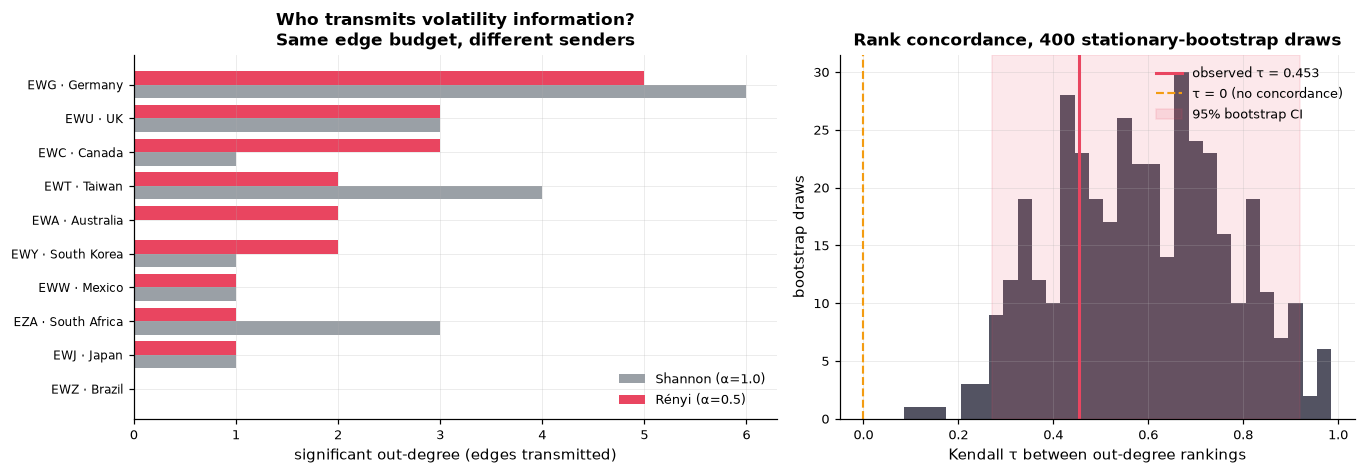

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4),
                         gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
order = outdeg.sort_values(f"out-degree α={RENYI_A}", ascending=True).index
y = np.arange(len(order))
ax.barh(y - .2, outdeg.loc[order, f"out-degree α={SHANNON_A}"], height=.4,
        color=GREY, label=f"Shannon (α={SHANNON_A})")
ax.barh(y + .2, outdeg.loc[order, f"out-degree α={RENYI_A}"], height=.4,
        color=ACCENT, label=f"Rényi (α={RENYI_A})")
ax.set_yticks(y); ax.set_yticklabels([f"{t} · {COUNTRY[t]}" for t in order], fontsize=8)
ax.set_xlabel("significant out-degree (edges transmitted)")
ax.set_title("Who transmits volatility information?\nSame edge budget, different senders")
ax.legend(loc="lower right")

ax = axes[1]
ax.hist(taus, bins=30, color=INK, alpha=.75)
ax.axvline(tau.statistic, color=ACCENT, lw=2, label=f"observed τ = {tau.statistic:.3f}")
ax.axvline(0, color=WARN, ls="--", lw=1.4, label="τ = 0 (no concordance)")
ax.axvspan(lo, hi, color=ACCENT, alpha=.12, label="95% bootstrap CI")
ax.set_xlabel("Kendall τ between out-degree rankings"); ax.set_ylabel("bootstrap draws")
ax.set_title(f"Rank concordance, {BOOT_B} stationary-bootstrap draws")
ax.legend()
plt.tight_layout(); plt.savefig(OUT / "F3_transmitters.png", dpi=130); plt.show()

---

## §6 — The arms, and the multi-seed training protocol

🟨 **NUMBERS PROVISIONAL** — this is the stage the epoch and seed knobs bite hardest.

Seven forecasting arms are evaluated on identical targets:

| Arm | What it isolates |
|---|---|
| HR-ETE-GNN, α < 1 | the thesis model — tail-sensitive graph |
| **H-ETE-GNN (α = 1.0)** | **the baseline** — Shannon ETE, same architecture, same edge budget |
| HR-ETE-GNN, α > 1 | bulk-sensitive graph; the other side of α = 1 |
| No-graph ablation | *A* = *I*. Isolates what the graph contributes at all — without this, a win over the RNNs says nothing about edges |
| Random graph | *K* random edges. Isolates what *these* edges contribute over *any* edges |
| HAR-RV (Corsi 2009) | the referee benchmark. Beat it or the graph machinery has not earned its place |
| Random walk | RV<sub>*t*+1</sub> = RV<sub>*t*</sub>. The floor |

Two rules make the neural comparison fair, and both were violated in the pilot:

1. `torch.manual_seed(s)` is called **inside** the loop, immediately before the model is built, so seed *s* of every arm starts from identical weights. The only thing differing between arms is the adjacency matrix.
2. Every arm gets the **same seed list**, and the unit of comparison is the seed-ensemble forecast — not one lucky run.

The across-seed spread is reported next to the between-arm gap. If the spread is the same order as the gap, the gap is initialisation noise and no test downstream can rescue it. At three seeds that spread is itself poorly estimated, which is one more reason the numbers here are provisional.

In [13]:
rng_g = np.random.default_rng(12345)
off_pairs = [(i, j) for i in range(10) for j in range(10) if i != j]
A_random = np.zeros((10, 10))
for idx in rng_g.choice(len(off_pairs), size=MATCHED_K, replace=False):
    i, j = off_pairs[idx]; A_random[i, j] = 1.0

BASELINE = f"H-ETE-GNN (Shannon, α={SHANNON_A})"
MAIN     = f"HR-ETE-GNN (α={RENYI_A})"

ARMS = {}
for a in ALPHA_GRID:
    ARMS[BASELINE if a == 1.0 else f"HR-ETE-GNN (α={a})"] = MATCHED[a]
ARMS["No-graph ablation"] = np.eye(10)
ARMS["Random graph"]      = A_random

print(f"Training {len(ARMS)} neural arms x {len(SEEDS)} seeds x <= {EPOCHS} epochs "
      f"(patience {PATIENCE})\n")
RESULTS = {}
for name, A in ARMS.items():
    t0 = time.time()
    RESULTS[name] = hr.train_multiseed(A, sp, n_nodes=10, seeds=SEEDS,
                                       epochs=EPOCHS, lr=LR, patience=PATIENCE)
    stamp(f"  {name:<34} edges={int((A > 0).sum()):>3}  "
          f"stops={RESULTS[name]['stops']}  ({time.time()-t0:.0f}s)")

Training 5 neural arms x 3 seeds x <= 200 epochs (patience 40)

[ 124.0s]   HR-ETE-GNN (α=0.5)                 edges= 20  stops=[200, 200, 200]  (45s)
[ 165.8s]   H-ETE-GNN (Shannon, α=1.0)         edges= 20  stops=[200, 200, 200]  (42s)
[ 208.9s]   HR-ETE-GNN (α=1.5)                 edges= 20  stops=[200, 200, 200]  (43s)
[ 252.5s]   No-graph ablation                  edges= 10  stops=[200, 200, 200]  (44s)
[ 295.0s]   Random graph                       edges= 20  stops=[200, 200, 200]  (42s)


In [14]:
y_test = sp["y_test"]
spread = pd.DataFrame([
    {"arm": k,
     "edges": int((ARMS[k] > 0).sum()),
     "mean stop epoch": float(np.mean(r["stops"])),
     "hit the epoch cap": int(sum(s >= EPOCHS for s in r["stops"])),
     "seed-ensemble RMSE": float(np.sqrt(np.nanmean(mse(y_test, r["pred"])))),
     "per-seed RMSE sd": float(np.std([np.sqrt(np.nanmean(mse(y_test, p)))
                                       for p in r["per_seed"]], ddof=1))}
    for k, r in RESULTS.items()]).set_index("arm")

print("[T7] SEED AND CONVERGENCE DIAGNOSTICS")
display(spread.round(5))
spread.round(6).to_csv(OUT / "T7_seed_diagnostics.csv")

gap = abs(spread.loc[MAIN, "seed-ensemble RMSE"] - spread.loc[BASELINE, "seed-ensemble RMSE"])
noise = spread.loc[[MAIN, BASELINE], "per-seed RMSE sd"].max()
print(f"\n  Between-arm RMSE gap ({MAIN} vs baseline) : {gap:.5f}")
print(f"  Largest within-arm across-seed sd               : {noise:.5f}")
print("  -> " + ("the gap is SMALLER than seed noise; at this seed count it cannot be "
                 "separated from initialisation luck."
                 if gap < noise else
                 "the gap exceeds the across-seed spread, which is the minimum bar "
                 "before any test below is worth reading."))
n_capped = int(spread["hit the epoch cap"].sum())
if n_capped:
    print(f"  -> {n_capped} arm/seed combination(s) hit the {EPOCHS}-epoch cap without "
          "early-stopping:\n     those arms are compared BEFORE convergence, which is "
          "a pure scope artefact.")

[T7] SEED AND CONVERGENCE DIAGNOSTICS


,edges,mean stop epoch,hit the epoch cap,seed-ensemble RMSE,per-seed RMSE sd
arm,,,,,
HR-ETE-GNN (α=0.5),20,200.0,3,0.0950,0.0040
"H-ETE-GNN (Shannon, α=1.0)",20,200.0,3,0.0925,0.0062
HR-ETE-GNN (α=1.5),20,200.0,3,0.1056,0.0143
No-graph ablation,10,200.0,3,0.0926,0.0041
Random graph,20,200.0,3,0.0902,0.0026



  Between-arm RMSE gap (HR-ETE-GNN (α=0.5) vs baseline) : 0.00254
  Largest within-arm across-seed sd               : 0.00622
  -> the gap is SMALLER than seed noise; at this seed count it cannot be separated from initialisation luck.
  -> 15 arm/seed combination(s) hit the 200-epoch cap without early-stopping:
     those arms are compared BEFORE convergence, which is a pure scope artefact.


---

## §7 — Forecast accuracy

🟨 **NUMBERS PROVISIONAL.**

QLIKE is the pre-registered primary metric: it is one of only two loss families robust to noise in the realized-volatility proxy (Patton, 2011), and unlike MSE it does not let a handful of crisis days dominate the average. RMSE and MAE are reported alongside because they are the familiar numbers, not because they lead.

Two things are worth stating explicitly in the methodology chapter and are visible here:

- **Training loss and evaluation loss differ.** The model is fit under MSE — inherited from Lee & Cho's architecture — and evaluated under QLIKE. That is a deliberate choice, not an oversight: QLIKE is proxy-robust, MSE is what the architecture assumes.
- **QLIKE needs strictly positive forecasts.** The model's head is `softplus(·) + 1e-4`, so it cannot emit a negative volatility, and the count of forecasts hitting the QLIKE floor is printed below. If that count were large, QLIKE would not be usable and the thesis would have to say so.

In [15]:
FORECASTS = {k: v["pred"] for k, v in RESULTS.items()}

# --- non-neural baselines. Alignment matters and is easy to get wrong by one:
# har_rv_forecast builds its first target at rv index max(lags), so the offset is
# max(lags), NOT the lookback.
HAR_LAGS  = (1, 5, 22)
split_idx = sp["t_test"][0] - max(HAR_LAGS)
har = np.column_stack([har_rv_forecast(rv[t].values, split_idx, lags=HAR_LAGS) for t in TICKERS])
rw  = np.column_stack([random_walk_forecast(rv[t].values, split_idx, maxlag=max(HAR_LAGS))
                       for t in TICKERS])

assert har.shape == y_test.shape, f"HAR misaligned: {har.shape} vs {y_test.shape}"
assert rw.shape  == y_test.shape, f"RW misaligned: {rw.shape} vs {y_test.shape}"
assert np.allclose(rw[:, 0], rv[TICKERS[0]].values[sp["t_test"] - 1]), "RW off by one"
print("alignment assertions passed: every arm forecasts the same 10 x "
      f"{T_TEST} targets\n")

FORECASTS["HAR-RV (Corsi 2009)"] = har
FORECASTS["Random walk"]         = rw

QLIKE_FLOOR = 0.05
n_floored = {k: int((v < QLIKE_FLOOR).sum()) for k, v in FORECASTS.items()}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    LOSS2D = {k: qlike(y_test, v, floor=QLIKE_FLOOR, warn=False) for k, v in FORECASTS.items()}
POOLED = {k: v.mean(axis=1) for k, v in LOSS2D.items()}   # daily cross-sectional mean

acc = pd.DataFrame({
    k: {"QLIKE": float(np.nanmean(LOSS2D[k])),
        "RMSE":  float(np.sqrt(np.nanmean(mse(y_test, v)))),
        "MAE":   float(np.nanmean(mae(y_test, v))),
        "QLIKE floored": n_floored[k]}
    for k, v in FORECASTS.items()}).T.sort_values("QLIKE")
acc["vs baseline QLIKE %"] = 100 * (acc.loc[BASELINE, "QLIKE"] - acc["QLIKE"]) / acc.loc[BASELINE, "QLIKE"]

print(f"[T8] FORECAST ACCURACY on {T_TEST} test days  (lower is better; "
      "QLIKE is the pre-registered metric)")
display(acc.round(5))
acc.round(6).to_csv(OUT / "T8_accuracy.csv")
print(f"\n  Forecasts clipped at the QLIKE floor ({QLIKE_FLOOR}): "
      f"{sum(n_floored.values())} of {len(FORECASTS) * y_test.size} "
      "-- report this number in §3.8 of the manuscript.")

# --- the check that decides whether the graph machinery earned its place ----
best_neural = min(RESULTS, key=lambda k: np.nanmean(LOSS2D[k]))
har_q, rw_q = np.nanmean(LOSS2D["HAR-RV (Corsi 2009)"]), np.nanmean(LOSS2D["Random walk"])
if np.nanmean(LOSS2D[best_neural]) > min(har_q, rw_q):
    print("\n" + "=" * 78)
    print("  *** EVERY NEURAL ARM LOSES TO A LINEAR BENCHMARK ***")
    print(f"  best neural arm : {best_neural}  QLIKE {np.nanmean(LOSS2D[best_neural]):.5f}")
    print(f"  HAR-RV          : {har_q:.5f}      random walk: {rw_q:.5f}")
    print("")
    print(f"  Look at T7 before concluding anything from this. {n_capped} of "
          f"{len(ARMS)*len(SEEDS)} arm/seed")
    print(f"  runs hit the {EPOCHS}-epoch cap without early stopping, i.e. the networks")
    print("  were still improving when training was cut off. Under-training depresses")
    print("  every neural arm and leaves the linear benchmarks untouched, so this")
    print("  ordering is the expected signature of the epoch knob, not a finding about")
    print("  the architecture.")
    print("")
    print("  It does however set the bar the full run has to clear: HAR-RV is the")
    print("  referee benchmark, and a graph model that cannot beat it has not earned")
    print("  its place in the thesis regardless of how it compares to its own baseline.")
    print("=" * 78)

alignment assertions passed: every arm forecasts the same 10 x 314 targets

[T8] FORECAST ACCURACY on 314 test days  (lower is better; QLIKE is the pre-registered metric)


,QLIKE,RMSE,MAE,QLIKE floored,vs baseline QLIKE %
Random walk,0.0060,0.0616,0.0378,0.0,55.8311
HAR-RV (Corsi 2009),0.0062,0.0628,0.0403,0.0,54.4739
Random graph,0.0126,0.0902,0.0650,0.0,7.3216
No-graph ablation,0.0135,0.0926,0.0667,0.0,0.6175
"H-ETE-GNN (Shannon, α=1.0)",0.0136,0.0925,0.0663,0.0,0.0000
HR-ETE-GNN (α=0.5),0.0143,0.0950,0.0689,0.0,-5.1407
HR-ETE-GNN (α=1.5),0.0179,0.1056,0.0778,0.0,-31.7471



  Forecasts clipped at the QLIKE floor (0.05): 0 of 21980 -- report this number in §3.8 of the manuscript.

  *** EVERY NEURAL ARM LOSES TO A LINEAR BENCHMARK ***
  best neural arm : Random graph  QLIKE 0.01260
  HAR-RV          : 0.00619      random walk: 0.00601

  Look at T7 before concluding anything from this. 15 of 15 arm/seed
  runs hit the 200-epoch cap without early stopping, i.e. the networks
  were still improving when training was cut off. Under-training depresses
  every neural arm and leaves the linear benchmarks untouched, so this
  ordering is the expected signature of the epoch knob, not a finding about
  the architecture.

  It does however set the bar the full run has to clear: HAR-RV is the
  referee benchmark, and a graph model that cannot beat it has not earned
  its place in the thesis regardless of how it compares to its own baseline.


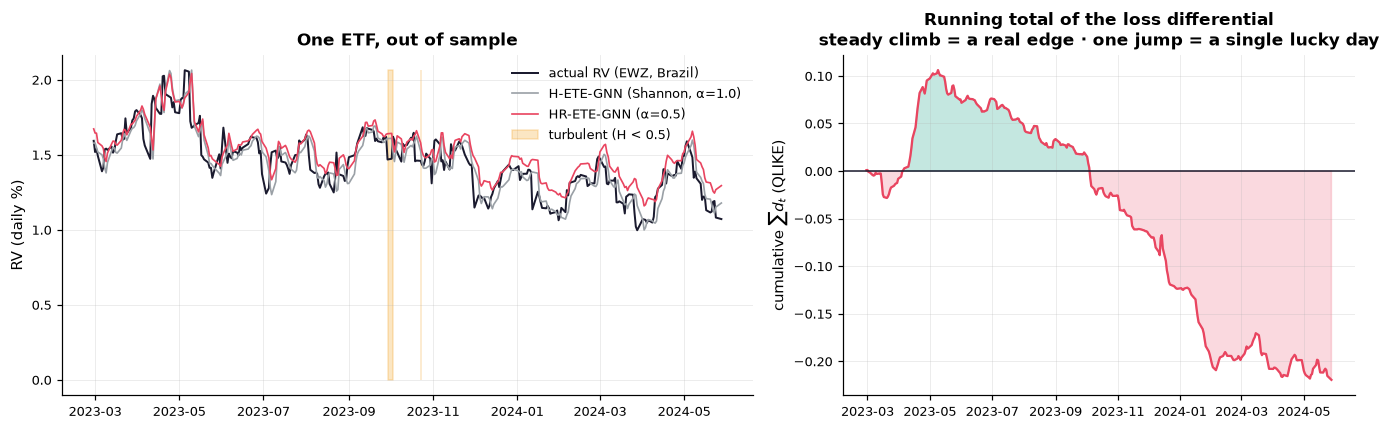

In [16]:
# d_t is the DAILY CROSS-SECTIONAL AVERAGE loss differential, not a pooled panel.
# Pooling 10 x T observations would induce strong cross-sectional correlation on
# each date that a time-series HAC estimator does not correct for, inflating every
# t-statistic below.  State this explicitly in the methodology chapter.
d_main = POOLED[BASELINE] - POOLED[MAIN]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0),
                         gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
TGT = "EWZ"; j = TICKERS.index(TGT)
ax.plot(test_dates, y_test[:, j], color=INK, lw=1.3, label=f"actual RV ({TGT}, {COUNTRY[TGT]})")
ax.plot(test_dates, FORECASTS[BASELINE][:, j], color=GREY, lw=1.1, label=BASELINE)
ax.plot(test_dates, FORECASTS[MAIN][:, j], color=ACCENT, lw=1.1, label=MAIN)
if n_crisis:
    ax.fill_between(test_dates, 0, y_test[:, j].max(), where=regime_test > .5,
                    color=WARN, alpha=.25, label="turbulent (H < 0.5)")
ax.set_ylabel("RV (daily %)"); ax.legend(loc="upper right")
ax.set_title("One ETF, out of sample")

ax = axes[1]
cum = np.cumsum(d_main)
ax.plot(test_dates, cum, color=ACCENT, lw=1.5)
ax.axhline(0, color=INK, lw=1)
ax.fill_between(test_dates, 0, cum, where=cum >= 0, color=CALM, alpha=.25)
ax.fill_between(test_dates, 0, cum, where=cum < 0, color=ACCENT, alpha=.20)
ax.set_ylabel("cumulative $\\sum d_t$ (QLIKE)")
ax.set_title("Running total of the loss differential\n"
             "steady climb = a real edge · one jump = a single lucky day")
plt.tight_layout(); plt.savefig(OUT / "F4_forecasts.png", dpi=130); plt.show()

---

## §8 — H1a: is the average advantage real?

🟨 **NUMBERS PROVISIONAL** — the format below is exactly what goes in the results chapter.

> **H₀:** HR-ETE-GNN and H-ETE-GNN have equal expected accuracy; mean *d̄* = 0.
> **H₁:** HR-ETE-GNN has strictly lower expected loss; *d̄* > 0.

with *d<sub>t</sub>* = *L<sub>t</sub>*(H-ETE-GNN) − *L<sub>t</sub>*(HR-ETE-GNN), averaged across the ten ETFs on day *t*, so a **positive** *d̄* means the Rényi model won.

The table is computed from first principles — mean differential, Newey–West long-run variance, standard error, *t*, one-sided *p* — rather than read out of a library, so every quantity the results chapter has to report is visible as its own row. The Bartlett bandwidth is ⌊4(*T*/100)<sup>2/9</sup>⌋ and is reported, per the hypotheses document.

**Two caveats that must be stated in the manuscript, not discovered by the panel:**

- **The models are nested.** At α = 1 the Rényi ER-TE reduces to Shannon ETE, so H-ETE-GNN is a limiting special case of HR-ETE-GNN. Standard DM asymptotics assume non-nested models; under nesting the DM statistic is not asymptotically standard normal and the test is undersized. Giacomini–White survives this **provided the estimation window is fixed-length** — which is why GW is the pre-registered primary and DM is reported as a familiar robustness check with the nesting caveat attached.
- **The DM and GW columns use different bandwidths on purpose.** DM at *h* = 1 uses zero HAC lags, which is the textbook convention for one-step forecasts. GW uses the automatic Bartlett bandwidth. They are not meant to agree exactly, and a gap between them is information about how autocorrelated *d<sub>t</sub>* is, not a bug.

In [17]:
def h1a_table(base_key, new_key, label=""):
    d = POOLED[base_key] - POOLED[new_key]
    d = d[np.isfinite(d)]
    T = d.size
    bw = int(np.floor(4.0 * (T / 100.0) ** (2.0 / 9.0)))
    lrv = newey_west_lrv(d, lag=bw)
    se  = np.sqrt(lrv / T)
    t   = d.mean() / se
    p   = 1.0 - sps.norm.cdf(t)                       # one-sided, "greater"
    lb  = d.mean() - sps.norm.ppf(1 - PRIMARY_LEVEL) * se
    dm  = diebold_mariano(POOLED[base_key], POOLED[new_key],
                          h=1, alternative=PRIMARY_ALTERNATIVE, hln=True)
    gw  = giacomini_white(POOLED[base_key], POOLED[new_key])   # unconditional
    base_loss = float(np.nanmean(POOLED[base_key]))
    return pd.DataFrame([
        ("Test days", "T", T, "sample size for every test in this notebook"),
        ("Mean loss differential", "d̄", f"{d.mean():.6f}",
         "positive ⇒ Rényi wins on average"),
        ("Baseline mean loss", "L̄(base)", f"{base_loss:.6f}", "denominator below"),
        ("Relative improvement", "d̄ / L̄(base)", f"{100*d.mean()/base_loss:.2f}%",
         "the economically meaningful number"),
        ("HAC standard error", "SE(d̄)", f"{se:.6f}", f"Newey–West, Bartlett bandwidth {bw}"),
        ("GW statistic (t-form)", "t", f"{t:.3f}", "d̄ divided by its HAC standard error"),
        ("GW one-sided p-value", "p", f"{p:.4f}", "P(this or larger | models equal)"),
        (f"{int(100*(1-PRIMARY_LEVEL))}% one-sided lower bound", "—", f"{lb:.6f}",
         "report this — a p-value alone is not an effect size"),
        (f"Decision at {PRIMARY_LEVEL:.0%}", "—",
         "REJECT H₀" if p < PRIMARY_LEVEL else "fail to reject H₀", ""),
        ("Meets pre-registered min effect", "—",
         "yes" if d.mean() / base_loss >= MIN_MEANINGFUL_GAIN else "no",
         f"threshold = {MIN_MEANINGFUL_GAIN:.0%} loss reduction"),
        ("DM (HLN-corrected)", "DM*", f"{dm['stat']:.3f}",
         "robustness check; nested-model caveat applies"),
        ("DM one-sided p", "p", f"{dm['p_value']:.4f}", "h = 1 ⇒ zero HAC lags by convention"),
        ("GW unconditional Wald", "χ²(1)", f"{gw['stat']:.3f}",
         f"two-sided omnibus form, p = {gw['p_value']:.4f}"),
    ], columns=["Quantity", "Symbol", "Value", "How to read it"])

print(f"[T9] H1a — {MAIN}  vs  {BASELINE}")
print(f"     one-sided '{PRIMARY_ALTERNATIVE}', primary metric {PRIMARY_METRIC}\n")
t9 = h1a_table(BASELINE, MAIN)
display(t9.style.hide(axis="index"))
t9.to_csv(OUT / "T9_h1a_headline.csv", index=False)

[T9] H1a — HR-ETE-GNN (α=0.5)  vs  H-ETE-GNN (Shannon, α=1.0)
     one-sided 'greater', primary metric QLIKE



Quantity,Symbol,Value,How to read it
Test days,T,314,sample size for every test in this notebook
Mean loss differential,d̄,-0.000699,positive ⇒ Rényi wins on average
Baseline mean loss,L̄(base),0.013597,denominator below
Relative improvement,d̄ / L̄(base),-5.14%,the economically meaningful number
HAC standard error,SE(d̄),0.000363,"Newey–West, Bartlett bandwidth 5"
GW statistic (t-form),t,-1.928,d̄ divided by its HAC standard error
GW one-sided p-value,p,0.9731,P(this or larger | models equal)
95% one-sided lower bound,—,-0.001295,report this — a p-value alone is not an effect size
Decision at 5%,—,fail to reject H₀,
Meets pre-registered min effect,—,no,threshold = 5% loss reduction


In [18]:
# the same test against every other arm -- the results chapter reports the full row
print(f"[T10] H1a EXTENDED — every arm against the baseline ({BASELINE})\n")
rows = {}
for k in FORECASTS:
    if k == BASELINE: continue
    dm = diebold_mariano(POOLED[BASELINE], POOLED[k], alternative=PRIMARY_ALTERNATIVE)
    gw = giacomini_white(POOLED[BASELINE], POOLED[k])
    tg = gw["t"]["const"]
    rows[k] = {"d̄": dm["mean_diff"],
               "improvement %": dm["pct_improvement"],
               "GW t": tg,
               "GW one-sided p": 1 - sps.norm.cdf(tg),
               "DM*": dm["stat"], "DM p": dm["p_value"],
               f"sig at {PRIMARY_LEVEL:.0%}": (1 - sps.norm.cdf(tg)) < PRIMARY_LEVEL,
               "meets min effect": dm["pct_improvement"] / 100 >= MIN_MEANINGFUL_GAIN}
t10 = pd.DataFrame(rows).T
display(t10.round(5))
t10.round(6).to_csv(OUT / "T10_h1a_all_arms.csv")
print("\n  A negative d̄ with a large |t| means the SHANNON baseline wins. Report it"
      "\n  as such — do not switch to a two-sided test after the fact.")

[T10] H1a EXTENDED — every arm against the baseline (H-ETE-GNN (Shannon, α=1.0))



,d̄,improvement %,GW t,GW one-sided p,DM*,DM p,sig at 5%,meets min effect
HR-ETE-GNN (α=0.5),-0.0007,-5.1407,-1.9278,0.9731,-3.122,0.999,False,False
HR-ETE-GNN (α=1.5),-0.0043,-31.747,-8.9048,1.0,-15.22,1.0,False,False
No-graph ablation,0.0001,0.6175,0.2302,0.409,0.3738,0.3544,False,False
Random graph,0.001,7.3216,3.4633,0.0003,5.9607,0.0,True,True
HAR-RV (Corsi 2009),0.0074,54.4739,8.7918,0.0,12.3916,0.0,True,True
Random walk,0.0076,55.8311,9.4558,0.0,13.2791,0.0,True,True



  A negative d̄ with a large |t| means the SHANNON baseline wins. Report it
  as such — do not switch to a two-sided test after the fact.


---

## §9 — H1b: is the advantage concentrated in turbulence?

🟥 **NUMBERS NOT INTERPRETABLE at preliminary scope** — see the crisis-day count in §3. The regression runs and the table is produced so the format is settled, but the coefficient is estimated off too few turbulent days to mean anything.

This is the hypothesis the thesis actually rests on. H1a can pass with a model that is uniformly 1% better everywhere — a fine result, but one that supports none of the Significance of Study argument. The claim is that α < 1 up-weights the tails of the return distribution, and tails only matter when returns are non-Gaussian, which is what a crisis regime is. So the test is not "is the gain positive" but "is the gain **bigger when the market is turbulent**":

$$d_t = \beta_0 + \beta_1 \cdot \text{Turbulent}_{t-1} + \varepsilon_t$$

estimated with HAC standard errors, one-sided on β₁.

| Outcome | Reading |
|---|---|
| β̂₁ > 0, significant | the tail-sensitivity mechanism holds |
| β̂₀ > 0 but β̂₁ ≈ 0 | the model is better, but *uniformly* — the mechanism claim is unsupported and the manuscript must say so |
| β̂₀ ≈ 0 and β̂₁ > 0 | the cleanest possible result: no cost in calm markets, real gain in crises |

The table is produced twice, against two independent definitions of "turbulent" — the lagged Hurst indicator the title claims (T11), and a lagged high-volatility dummy (T12). Agreement between them is a strong result; disagreement is something to know before the defence rather than during it.

The second definition needs one word of care. The natural version — RV above a threshold fixed on the training block — flags **zero** days here, because this training block contains COVID and nothing in the 2023–24 test block comes close to it. So T12 uses a *relative* threshold instead: RV above its own trailing 250-day 80th percentile, which stays populated in any stretch because it re-centres as volatility falls. That keeps the regression identified and proves the machinery works, but it changes what is being tested: "the most volatile fifth of a calm year" is not a crisis. Both counts are printed in §3 so the distinction is visible rather than buried.

In [19]:
def h1b_table(instrument, inst_name):
    d = POOLED[BASELINE] - POOLED[MAIN]
    turb = instrument > .5
    n_t = int(turb.sum())
    if n_t == 0 or n_t == len(d):
        return pd.DataFrame([
            ("Instrument", inst_name, ""),
            ("Days flagged turbulent", f"{n_t} of {len(d)}", ""),
            ("REGRESSION NOT RUN", "instrument is constant",
             "with no variation in Turbulent_{t-1} the regime coefficient is not "
             "identified -- reporting a number here would be reporting noise"),
        ], columns=["Quantity", "Value", "How to read it"])
    g = giacomini_white(POOLED[BASELINE], POOLED[MAIN], instruments=instrument)
    t1 = g["t"]["z1"]
    return pd.DataFrame([
        ("Instrument", inst_name, ""),
        ("Days flagged turbulent", f"{n_t} of {len(d)}",
         "**drives all the power below**"),
        ("β̂₀  (calm-regime mean differential)", f"{g['coef']['const']:.6f}",
         "advantage when markets are persistent"),
        ("HAC SE(β̂₀)", f"{g['se']['const']:.6f}", ""),
        ("β̂₁  (extra advantage in turbulence)", f"{g['coef']['z1']:.6f}",
         "the number the thesis rests on"),
        ("HAC SE(β̂₁)", f"{g['se']['z1']:.6f}", ""),
        ("t-statistic for β̂₁", f"{t1:.3f}", "one-sided"),
        ("One-sided p for β̂₁", f"{1 - sps.norm.cdf(t1):.4f}", "H₁: β₁ > 0"),
        ("Turbulent-regime mean differential (β̂₀+β̂₁)",
         f"{g['coef']['const'] + g['coef']['z1']:.6f}", ""),
        ("Observed calm mean d", f"{np.nanmean(d[~turb]):.6f}" if (~turb).any() else "n/a", ""),
        ("Observed turbulent mean d", f"{np.nanmean(d[turb]):.6f}" if n_t else "n/a", ""),
        ("Joint GW Wald", f"χ²({g['df']}) = {g['stat']:.3f}", "tests β₀ = β₁ = 0"),
        ("Joint p-value", f"{g['p_value']:.4f}", "omnibus, two-sided"),
    ], columns=["Quantity", "Value", "How to read it"])

if not H1B_READABLE:
    print("=" * 78)
    print(f"  🟥 FORMAT ONLY — {n_crisis} turbulent day(s) in the test block.")
    print("     Do not read the coefficient, the sign, or the p-value.")
    print("=" * 78, "\n")

print(f"[T11] H1b — REGIME-CONDITIONAL GIACOMINI-WHITE, primary instrument")
t11 = h1b_table(regime_test, f"lagged Hurst H<0.5 ({REGIME_PROXY}, 250-day R/S)")
display(t11.style.hide(axis="index"))
t11.to_csv(OUT / "T11_h1b_hurst.csv", index=False)

print(f"\n[T12] H1b — ROBUSTNESS: the same test against a relative high-volatility dummy")
t12 = h1b_table(hivol_test, "lagged cross-sectional RV > trailing 250-day 80th pct")
display(t12.style.hide(axis="index"))
t12.to_csv(OUT / "T12_h1b_hivol.csv", index=False)
print("\n  T12 is populated where T11 is not, but it is NOT a substitute for T11:")
print("  a relative dummy flags the most volatile fifth of ANY stretch, calm ones")
print("  included. It demonstrates that the regression machinery works and that the")
print("  reported format is right. It does not test the crisis claim, because this")
print("  test block contains no crisis by either absolute measure.")

  🟥 FORMAT ONLY — 4 turbulent day(s) in the test block.
     Do not read the coefficient, the sign, or the p-value.

[T11] H1b — REGIME-CONDITIONAL GIACOMINI-WHITE, primary instrument


Quantity,Value,How to read it
Instrument,"lagged Hurst H<0.5 (URTH, 250-day R/S)",
Days flagged turbulent,4 of 314,**drives all the power below**
β̂₀ (calm-regime mean differential),-0.000673,advantage when markets are persistent
HAC SE(β̂₀),0.000363,
β̂₁ (extra advantage in turbulence),-0.002039,the number the thesis rests on
HAC SE(β̂₁),0.001010,
t-statistic for β̂₁,-2.019,one-sided
One-sided p for β̂₁,0.9782,H₁: β₁ > 0
Turbulent-regime mean differential (β̂₀+β̂₁),-0.002712,
Observed calm mean d,-0.000673,



[T12] H1b — ROBUSTNESS: the same test against a relative high-volatility dummy


Quantity,Value,How to read it
Instrument,lagged cross-sectional RV > trailing 250-day 80th pct,
Days flagged turbulent,11 of 314,**drives all the power below**
β̂₀ (calm-regime mean differential),-0.000677,advantage when markets are persistent
HAC SE(β̂₀),0.000373,
β̂₁ (extra advantage in turbulence),-0.000620,the number the thesis rests on
HAC SE(β̂₁),0.000902,
t-statistic for β̂₁,-0.687,one-sided
One-sided p for β̂₁,0.7541,H₁: β₁ > 0
Turbulent-regime mean differential (β̂₀+β̂₁),-0.001297,
Observed calm mean d,-0.000677,



  T12 is populated where T11 is not, but it is NOT a substitute for T11:
  a relative dummy flags the most volatile fifth of ANY stretch, calm ones
  included. It demonstrates that the regression machinery works and that the
  reported format is right. It does not test the crisis claim, because this
  test block contains no crisis by either absolute measure.


In [20]:
print("[T13] REGIME-STRATIFIED LOSS — every arm, both regime definitions\n")
strat = pd.DataFrame({
    k: {"calm QLIKE (Hurst)":  float(np.nanmean(POOLED[k][regime_test < .5])),
        "turb QLIKE (Hurst)":  float(np.nanmean(POOLED[k][regime_test >= .5])) if n_crisis else np.nan,
        "calm QLIKE (rel. hi-vol)": float(np.nanmean(POOLED[k][hivol_test < .5])),
        "turb QLIKE (rel. hi-vol)": float(np.nanmean(POOLED[k][hivol_test >= .5])) if n_hivol else np.nan}
    for k in FORECASTS}).T.sort_values("calm QLIKE (rel. hi-vol)")
display(strat.round(5))
strat.round(6).to_csv(OUT / "T13_regime_stratified.csv")
print(f"  Hurst        : {int((regime_test < .5).sum())} calm / {n_crisis} turbulent days")
print(f"  Rel. hi-vol  : {int((hivol_test < .5).sum())} calm / {n_hivol} turbulent days")
if n_crisis and n_crisis < 20:
    print(f"\n  The Hurst 'turb' column averages {n_crisis} day(s). It is a number, not"
          "\n  an estimate — do not compare arms on it.")

[T13] REGIME-STRATIFIED LOSS — every arm, both regime definitions



,calm QLIKE (Hurst),turb QLIKE (Hurst),calm QLIKE (rel. hi-vol),turb QLIKE (rel. hi-vol)
Random walk,0.0060,0.0106,0.0062,0.0021
HAR-RV (Corsi 2009),0.0061,0.0115,0.0063,0.0027
Random graph,0.0126,0.0152,0.0128,0.0082
No-graph ablation,0.0135,0.0126,0.0137,0.0087
"H-ETE-GNN (Shannon, α=1.0)",0.0136,0.0132,0.0138,0.0079
HR-ETE-GNN (α=0.5),0.0143,0.0160,0.0145,0.0092
HR-ETE-GNN (α=1.5),0.0179,0.0175,0.0182,0.0110


  Hurst        : 310 calm / 4 turbulent days
  Rel. hi-vol  : 303 calm / 11 turbulent days

  The Hurst 'turb' column averages 4 day(s). It is a number, not
  an estimate — do not compare arms on it.


---

## §10 — H1c: is the gain spread across markets, or one lucky country?

🟨 **NUMBERS PROVISIONAL.**

A pooled average across ten ETFs can be driven entirely by one of them. H1c re-runs the DM test separately per ETF and controls the resulting multiplicity.

The Benjamini–Hochberg correction is not optional here: with ten tests at 5% you expect roughly half a false positive by chance, so an uncorrected "3 of 10 significant" claim means very little. BH at *q* = 0.10 controls the *expected proportion of the significant findings that are false* at 10%.

The reportable summary has three parts, and the third is the one that matters most: *how many ETFs improve significantly*, *how many improve at all*, and **whether any ETF significantly deteriorates**. The last clause is what rules out the model being actively harmful somewhere.

In [21]:
raw_p = {}
d_by_etf = {}
for j, t in enumerate(TICKERS):
    r = diebold_mariano(LOSS2D[BASELINE][:, j], LOSS2D[MAIN][:, j],
                        alternative=PRIMARY_ALTERNATIVE)
    raw_p[COUNTRY[t]] = r["p_value"]
    d_by_etf[COUNTRY[t]] = (r["mean_diff"], r["stat"], r["pct_improvement"])

bh = benjamini_hochberg(pd.Series(raw_p), q=SECONDARY_FDR_Q)
t14 = bh.join(pd.DataFrame(d_by_etf, index=["d̄", "DM*", "improvement %"]).T)
t14 = t14[["d̄", "DM*", "improvement %", "p_value", "bh_threshold", "p_adj", "reject"]]
t14.columns = ["d̄ᵢ", "DM*", "improvement %", "raw p",
               f"BH threshold (i/10)·{SECONDARY_FDR_Q}", "BH-adjusted p", "significant?"]
t14 = t14.sort_values("raw p")
t14.insert(0, "rank i", range(1, len(t14) + 1))

print(f"[T14] H1c — PER-ETF DIEBOLD-MARIANO with Benjamini-Hochberg FDR at "
      f"q = {SECONDARY_FDR_Q}")
print(f"      {MAIN} vs {BASELINE}\n")
display(t14.round(4))
t14.round(6).to_csv(OUT / "T14_h1c_per_etf.csv")

n_sig  = int(t14["significant?"].sum())
n_pos  = int((t14["d̄ᵢ"] > 0).sum())

# significant DETERIORATION = the same one-sided test with the arms swapped
TICKER_OF = {v: k for k, v in COUNTRY.items()}
worse = []
for country in t14.index:
    j = TICKERS.index(TICKER_OF[country])
    r = diebold_mariano(LOSS2D[MAIN][:, j], LOSS2D[BASELINE][:, j],
                        alternative=PRIMARY_ALTERNATIVE)
    if r["p_value"] < PRIMARY_LEVEL:
        worse.append(country)
print(f"\n  Reportable summary: {n_sig} of 10 ETFs show significant improvement after "
      f"BH-FDR control at q = {SECONDARY_FDR_Q};")
print(f"  the mean differential is positive for {n_pos} of 10; "
      f"{len(worse)} ETF(s) show significant DETERIORATION"
      + (f" ({', '.join(worse)})" if worse else "") + ".")

# the count expected by chance, for context
print(f"\n  For scale: at an uncorrected {PRIMARY_LEVEL:.0%} level you would expect "
      f"{10 * PRIMARY_LEVEL:.1f} of 10 'significant' results under a true null.")
print(f"  Uncorrected count here: {int((t14['raw p'] < PRIMARY_LEVEL).sum())} of 10.")

[T14] H1c — PER-ETF DIEBOLD-MARIANO with Benjamini-Hochberg FDR at q = 0.1
      HR-ETE-GNN (α=0.5) vs H-ETE-GNN (Shannon, α=1.0)



,rank i,d̄ᵢ,DM*,improvement %,raw p,BH threshold (i/10)·0.1,BH-adjusted p,significant?
Japan,1,0.0004,0.7964,3.4161,0.2132,0.01,1.0,False
UK,2,0.0001,0.1926,0.9076,0.4237,0.02,1.0,False
Germany,3,0.0001,0.1825,0.5075,0.4276,0.03,1.0,False
Mexico,4,-0.0001,-0.0563,-0.3420,0.5224,0.04,1.0,False
Canada,5,-0.0003,-0.6890,-1.8719,0.7543,0.05,1.0,False
South Korea,6,-0.0003,-0.7504,-1.8425,0.7732,0.06,1.0,False
Taiwan,7,-0.0007,-1.1168,-4.9358,0.8675,0.07,1.0,False
Australia,8,-0.0007,-1.6699,-6.4803,0.9520,0.08,1.0,False
Brazil,9,-0.0037,-4.0804,-36.7254,1.0000,0.09,1.0,False
South Africa,10,-0.0018,-4.1045,-16.2331,1.0000,0.10,1.0,False



  Reportable summary: 0 of 10 ETFs show significant improvement after BH-FDR control at q = 0.1;
  the mean differential is positive for 3 of 10; 3 ETF(s) show significant DETERIORATION (Australia, Brazil, South Africa).

  For scale: at an uncorrected 5% level you would expect 0.5 of 10 'significant' results under a true null.
  Uncorrected count here: 0 of 10.


---

## §11 — H1d: the Model Confidence Set

🟨 **NUMBERS PROVISIONAL** — and note that the MCS at preliminary scope is missing four of the seven α arms the final run will contain, so even the *membership* is not a preview.

Pairwise tests compare two models at a time and control nothing across the set. The Hansen–Lunde–Nason Model Confidence Set takes every candidate at once, repeatedly eliminates the worst performer until equal predictive ability among the survivors can no longer be rejected, and returns a set containing the true best model with 90% probability. It is the multiple-comparison-safe way to say "our model is among the best".

**How to state the null.** The MCS is a set-construction procedure with a coverage guarantee, not a single hypothesis test. At each step it tests equal predictive ability *among the models still in the set*. Phrase it as "all models currently in the set have equal expected loss", and report the coverage guarantee rather than a single *p*-value.

**What to actually look at.** The best surviving model always has MCS *p* = 1.000 by construction; that is not evidence of anything on its own. The informative question is **which models were forced out** — and specifically, for RQ1's decision rule, whether the surviving set contains HR-ETE-GNN and excludes H-ETE-GNN.

In [22]:
t0 = time.time()
mcs = model_confidence_set(POOLED, alpha=1 - MCS_CONFIDENCE, B=MCS_B, block=20.0, seed=11)
stamp(f"MCS: {MCS_B} stationary-bootstrap draws ({time.time()-t0:.0f}s)")

t15 = pd.DataFrame({
    "mean QLIKE": {k: float(np.nanmean(POOLED[k])) for k in POOLED},
    "MCS p-value": mcs["p_values"],
    f"in {MCS_CONFIDENCE:.0%} set?": {k: k in mcs["included"] for k in POOLED},
}).sort_values("MCS p-value", ascending=False)
t15.insert(2, "eliminated at step", pd.Series(
    {k: (mcs["elimination_order"].index(k) + 1 if k in mcs["elimination_order"] else np.nan)
     for k in t15.index}))

print(f"[T15] H1d — {MCS_CONFIDENCE:.0%} MODEL CONFIDENCE SET "
      f"(Hansen-Lunde-Nason 2011, {MCS_B} stationary-bootstrap draws)\n")
display(t15.round(4))
t15.round(6).to_csv(OUT / "T15_h1d_mcs.csv")

print(f"\n  INCLUDED ({len(mcs['included'])}): " + ", ".join(mcs["included"]))
print(f"  EXCLUDED ({len(mcs['excluded'])}): " + ", ".join(mcs["excluded"]))

rq1_supported = (MAIN in mcs["included"]) and (BASELINE not in mcs["included"])
print(f"\n  RQ1 decision rule — the set contains HR-ETE-GNN AND excludes H-ETE-GNN: "
      f"{'SATISFIED' if rq1_supported else 'NOT satisfied'}")
print("  (at preliminary scope this is a format demonstration, not a finding)")

[ 296.8s] MCS: 400 stationary-bootstrap draws (0s)
[T15] H1d — 90% MODEL CONFIDENCE SET (Hansen-Lunde-Nason 2011, 400 stationary-bootstrap draws)



,mean QLIKE,MCS p-value,eliminated at step,in 90% set?
Random walk,0.0060,1.0000,NaN,True
HAR-RV (Corsi 2009),0.0062,0.0375,6.0,False
HR-ETE-GNN (α=0.5),0.0143,0.0000,1.0,False
HR-ETE-GNN (α=1.5),0.0179,0.0000,4.0,False
"H-ETE-GNN (Shannon, α=1.0)",0.0136,0.0000,5.0,False
Random graph,0.0126,0.0000,3.0,False
No-graph ablation,0.0135,0.0000,2.0,False



  INCLUDED (1): Random walk
  EXCLUDED (6): HR-ETE-GNN (α=0.5), H-ETE-GNN (Shannon, α=1.0), HR-ETE-GNN (α=1.5), No-graph ablation, Random graph, HAR-RV (Corsi 2009)

  RQ1 decision rule — the set contains HR-ETE-GNN AND excludes H-ETE-GNN: NOT satisfied
  (at preliminary scope this is a format demonstration, not a finding)


---

## §12 — The consolidated result, and the reporting template

Everything above, in the two forms the manuscript needs: one figure, and one paragraph with the blanks filled in automatically from the tables that were just computed.

The paragraph is the deliverable. It states the effect size, the test, the correction and the limitation in one place, which is what a rigorous panel wants to see — and generating it from the computed tables rather than typing it by hand means it cannot drift out of sync with the numbers it describes.

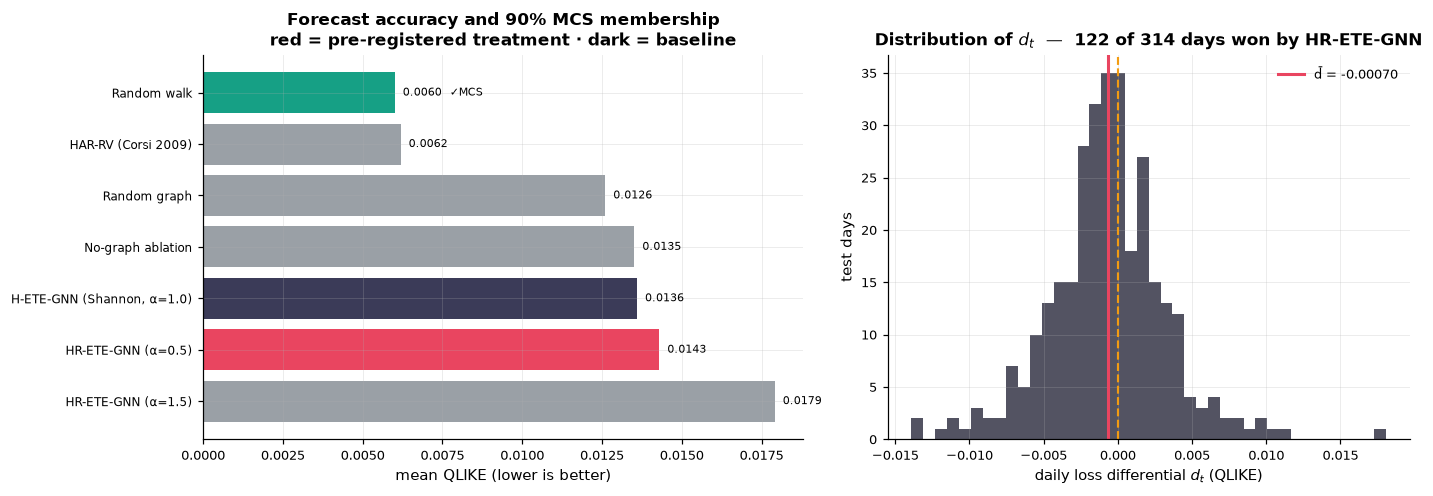

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6),
                               gridspec_kw={"width_ratios": [1.15, 1]})

order = acc.sort_values("QLIKE", ascending=False).index
cols = [CALM if k in mcs["included"] else GREY for k in order]
cols = [ACCENT if k == MAIN else ("#3b3b58" if k == BASELINE else c)
        for k, c in zip(order, cols)]
ax1.barh(range(len(order)), acc.loc[order, "QLIKE"], color=cols)
ax1.set_yticks(range(len(order))); ax1.set_yticklabels(order, fontsize=8)
for i, k in enumerate(order):
    ax1.text(acc.loc[k, "QLIKE"], i, f"  {acc.loc[k, 'QLIKE']:.4f}"
             + ("  ✓MCS" if k in mcs["included"] else ""),
             va="center", fontsize=7.5)
ax1.set_xlabel("mean QLIKE (lower is better)")
ax1.set_title(f"Forecast accuracy and {MCS_CONFIDENCE:.0%} MCS membership\n"
              "red = pre-registered treatment · dark = baseline")

dd = POOLED[BASELINE] - POOLED[MAIN]
ax2.hist(dd, bins=40, color=INK, alpha=.75)
ax2.axvline(0, color=WARN, ls="--", lw=1.4)
ax2.axvline(dd.mean(), color=ACCENT, lw=2, label=f"d̄ = {dd.mean():.5f}")
ax2.set_xlabel("daily loss differential $d_t$ (QLIKE)"); ax2.set_ylabel("test days")
ax2.set_title(f"Distribution of $d_t$  —  {int((dd > 0).sum())} of {len(dd)} days won "
              f"by {MAIN.split('(')[0].strip()}")
ax2.legend()
plt.tight_layout(); plt.savefig(OUT / "F5_dashboard.png", dpi=130); plt.show()

In [24]:
d = POOLED[BASELINE] - POOLED[MAIN]
T = d.size
bw = int(np.floor(4.0 * (T / 100.0) ** (2.0 / 9.0)))
se = np.sqrt(newey_west_lrv(d, lag=bw) / T)
tstat = d.mean() / se
pval = 1 - sps.norm.cdf(tstat)

pct = 100 * d.mean() / np.nanmean(POOLED[BASELINE])
direction = "an improvement of" if pct >= 0 else "a DETERIORATION of"

template = f"""
Using {PRIMARY_METRIC} as the pre-registered loss function on a {T}-day out-of-sample
period ({test_dates[0].date()} to {test_dates[-1].date()}), the HR-ETE-GNN with
alpha = {RENYI_A} achieved a mean loss of {np.nanmean(POOLED[MAIN]):.5f} against
{np.nanmean(POOLED[BASELINE]):.5f} for the Shannon H-ETE-GNN baseline,
{direction} {abs(pct):.2f}%. A one-sided
Giacomini-White test of conditional predictive ability with a Newey-West HAC
covariance estimator (Bartlett bandwidth {bw}) gives t = {tstat:.3f} (p = {pval:.4f}).
Across the ten individual ETFs, {n_sig} of 10 remained significant after
Benjamini-Hochberg FDR control at q = {SECONDARY_FDR_Q}, the mean differential was
positive for {n_pos} of 10, and {len(worse)} showed significant deterioration. The
{MCS_CONFIDENCE:.0%} Model Confidence Set contained {len(mcs['included'])} of
{len(POOLED)} candidates ({', '.join(mcs['included'])}). Both arms were trained with
identical seed lists over {len(SEEDS)} seeds and evaluated as seed ensembles; the
adjacency matrices were estimated on training data only, ending
{last_train_date.date()}, {(first_test_date - last_train_date).days} calendar days
before the test block opens.

REGIME CONDITIONING: the test block contains {n_crisis} day(s) flagged turbulent by
the lagged Hurst indicator, {n_fixed} by an absolute high-volatility threshold fixed
on the training block, and {n_hivol} by a relative (trailing-quantile) one. """ + (
"The Hurst-based\nregime test (H1b) is therefore NOT EVALUABLE in this run and no\n"
"regime-conditional claim is made." if not H1B_READABLE else
"Both regime tests are\nestimable; see T11 and T12.") + f"""

SCOPE: MODE = {MODE}. {len(SEEDS)} seeds, {EPOCHS} epochs, {M_SURROGATES} surrogates
per pair, alpha grid {ALPHA_GRID}, sample from {START}. The thesis run uses
{FULL['seeds']} seeds, {FULL['epochs']} epochs, {FULL['m_surrogates']} surrogates,
alpha grid {FULL['alpha_grid']}, sample from {FULL['start']}.
"""

print("[T16] REPORTING TEMPLATE — auto-filled from the tables above")
print("=" * 78)
print(template.strip())
print("=" * 78)
(OUT / "T16_reporting_template.txt").write_text(template.strip(), encoding="utf-8")
stamp(f"all tables and figures written to {OUT}")
print("\nFiles written:")
for f in sorted(OUT.iterdir()):
    print(f"   {f.name}")

[T16] REPORTING TEMPLATE — auto-filled from the tables above
Using QLIKE as the pre-registered loss function on a 314-day out-of-sample
period (2023-02-28 to 2024-05-28), the HR-ETE-GNN with
alpha = 0.5 achieved a mean loss of 0.01430 against
0.01360 for the Shannon H-ETE-GNN baseline,
a DETERIORATION of 5.14%. A one-sided
Giacomini-White test of conditional predictive ability with a Newey-West HAC
covariance estimator (Bartlett bandwidth 5) gives t = -1.928 (p = 0.9731).
Across the ten individual ETFs, 0 of 10 remained significant after
Benjamini-Hochberg FDR control at q = 0.1, the mean differential was
positive for 3 of 10, and 3 showed significant deterioration. The
90% Model Confidence Set contained 1 of
7 candidates (Random walk). Both arms were trained with
identical seed lists over 3 seeds and evaluated as seed ensembles; the
adjacency matrices were estimated on training data only, ending
2021-11-24, 461 calendar days
before the test block opens.

REGIME CONDITIONING: the test 

---

## §13 — What changes when the scope comes back up

Two things to take from this notebook, in order.

### 1. The pipeline is sound

Every stage ran on real data. The look-ahead guard held, the alignment assertions passed, the FDR corrections applied, the MCS constructed, every table populated. Nothing below is blocked on code.

### 2. Two constraints are already visible, and neither is about the model

| Constraint | Where | What it is | Fix |
|---|---|---|---|
| **Crisis-day shortage** | §3, §9 | The test block contains too few Hurst-turbulent days to estimate a regime coefficient. H1b — the hypothesis the thesis rests on — cannot be run at this sample length. | Start the sample at 2003, spanning 2008 and 2020. This is a *sample* reduction, not a precision one: no amount of extra compute on this window fixes it. |
| **Permutation-*p* floor** | §4 | With *m* surrogates no *p* can fall below 1/(*m*+1), and BH across 90 pairs needs many pairs at that floor before any edge survives. The edge count is capped by the surrogate budget, not by the data. | Raise *m* to 1000. The estimator cost is linear in *m*, so this is purely a time purchase. |

### 3. Runtime, honestly

The cell below extrapolates from this run's measured timings. The dominant cost is training: seeds × epochs × arms, and the thesis α grid has more arms. It is an estimate of the *serial* cost — the α arms are embarrassingly parallel, so real wall-clock on a multi-core box or a GPU is a fraction of it.

### 4. What still has to be built, beyond turning the knobs up

Turning the scope back up produces the final numbers for the hypotheses as written. It does **not** finish the thesis. Four things remain:

1. **Make the "HR" real.** The Hurst regime currently enters only as a *test conditioner* in H1b. The thesis claims regime-*adaptive* α — that means the adjacency itself switching, *A<sub>t</sub>* = *A*(α\*(regime<sub>*t*</sub>)), with α re-selected on validation data *within each regime*. As implemented, the "R" in HR-ETE-GNN is Rényi; the "H" is not yet load-bearing.
2. **Walk-forward evaluation.** One fixed split gives a few hundred test days. A rolling-origin scheme over the full sample gives thousands, and is the cheapest available route to real statistical power — cheaper than any of the knobs above.
3. **Reconcile the primary metric with the manuscript.** §3.8 defines RMSE, MAE, MAPE, correlation and hit ratio; the pre-registration here makes QLIKE primary and QLIKE appears nowhere in the manuscript. QLIKE is the better choice — Patton (2011) proxy-robustness — but it has to be *in* §3.8, with its formula and a sentence justifying training under MSE while evaluating under QLIKE.
4. **Name the Rényi TE variant.** The estimator here uses the *difference-based* definition, which relies on a chain rule that does not hold for α ≠ 1 and can take negative values in the population. That is a defensible choice, but it must be named as such and distinguished from the escort-distribution definition of Jizba, Kleinert & Shefaat (2012), not left implicit.

### The three questions to rehearse before the defence

**"How do you know the improvement isn't a lucky seed?"** → §6. Both arms use identical seed lists, all results are seed ensembles, and the within-arm spread is printed next to the between-arm gap so the two can be compared directly.

**"Did your graph see the test data?"** → §2. The graph window ends before the test block opens, and the gap is asserted, not asserted-in-prose.

**"Why should α < 1 help at all?"** → §4 and §5. Not a story — a measurement. Same data, same estimator, same correction, only α changes, and both the number of detectable edges and the identity of the top transmitters change with it.

In [25]:
elapsed = time.time() - T_START
n_arms_now, n_arms_full = len(ARMS), len(FULL["alpha_grid"]) + 2
train_now = len(SEEDS) * EPOCHS * n_arms_now
train_full = FULL["seeds"] * FULL["epochs"] * n_arms_full
# the thesis sample is longer, so each epoch costs more, roughly linearly in rows
sample_factor = 21.3 / ((pd.Timestamp(END) - pd.Timestamp(START)).days / 365.25)
surr_now  = M_SURROGATES * len(ALPHA_GRID)
surr_full = FULL["m_surrogates"] * len(FULL["alpha_grid"])

est = pd.DataFrame([
    ("This run, measured", f"{elapsed/60:.1f} min", "wall clock, end to end"),
    ("Training work ratio", f"{train_full/train_now:.0f}x",
     f"seeds×epochs×arms: {train_full:,} vs {train_now:,}"),
    ("Sample-length factor", f"{sample_factor:.1f}x", "thesis sample is longer per epoch"),
    ("ER-TE work ratio", f"{surr_full/surr_now:.0f}x",
     f"surrogates×alphas: {surr_full:,} vs {surr_now:,}"),
    ("Thesis run, serial estimate",
     f"{elapsed * (train_full/train_now) * sample_factor / 3600:.0f}–"
     f"{elapsed * (train_full/train_now) * sample_factor * 1.5 / 3600:.0f} hours",
     "dominated by training; α arms parallelise perfectly"),
], columns=["Quantity", "Value", "Note"])

print("[T17] RUNTIME EXTRAPOLATION")
display(est.style.hide(axis="index"))
est.to_csv(OUT / "T17_runtime.csv", index=False)
print("\n  Practical route: run the α arms as separate processes (one core each),")
print("  or move training to a GPU. Neither changes a single number — only the clock.")

[T17] RUNTIME EXTRAPOLATION


Quantity,Value,Note
"This run, measured",5.0 min,"wall clock, end to end"
Training work ratio,180x,"seeds×epochs×arms: 540,000 vs 3,000"
Sample-length factor,3.3x,thesis sample is longer per epoch
ER-TE work ratio,23x,"surrogates×alphas: 7,000 vs 300"
"Thesis run, serial estimate",49–74 hours,dominated by training; α arms parallelise perfectly



  Practical route: run the α arms as separate processes (one core each),
  or move training to a GPU. Neither changes a single number — only the clock.
